In [2]:
from pathlib import Path
import torch


REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "lpbf_to").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "lpbf_to").exists(), f"Repo root not found. Current: {Path.cwd()}"
print("REPO_ROOT =", REPO_ROOT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

from lpbf_to.losses.manufacturing_loss import ManufacturingLoss, Bounds
print("ManufacturingLoss import OK")



REPO_ROOT = /workspaces/lpbf_project
device = cpu
ManufacturingLoss import OK


In [3]:
import numpy as np
import torch

def inspect_tensor(x, name="tensor"):
    print(f"\n--- {name} inspect ---")
    print("type:", type(x))
    if not isinstance(x, torch.Tensor):
        print("Not a torch.Tensor")
        return

    print("shape:", tuple(x.shape))
    print("dtype:", x.dtype)
    print("device:", x.device)
    print("requires_grad:", x.requires_grad)

    with torch.no_grad():
        if x.dtype.is_floating_point or x.dtype.is_complex:
            print("min/mean/max:", float(x.min()), float(x.mean()), float(x.max()))
        else:
            print("min/max:", int(x.min()), int(x.max()))
            print("unique count:", int(torch.unique(x).numel()))

def make_tile_indices(shape, tile_shape):
    """
    Deterministically assigns each voxel/cell to a tile by splitting each axis into tile_shape bins.
    Supports shape = (X,Y) or (X,Y,Z).
    For 2D shapes, use tile_shape=(nx,ny,1).
    """
    if len(shape) == 2:
        X, Y = shape
        Z = 1
        is_2d = True
    elif len(shape) == 3:
        X, Y, Z = shape
        is_2d = False
    else:
        raise ValueError(f"rho shape must be 2D or 3D, got {shape}")

    nx, ny, nz = tile_shape
    if is_2d and nz != 1:
        raise ValueError("For 2D rho, use tile_shape nz=1 (e.g., (2,2,1)).")

    x_edges = np.linspace(0, X, nx + 1).astype(int)
    y_edges = np.linspace(0, Y, ny + 1).astype(int)
    z_edges = np.linspace(0, Z, nz + 1).astype(int)

    tile_idx = np.zeros((X, Y, Z), dtype=np.int64)

    def tid(ix, iy, iz):
        return ix + nx * (iy + ny * iz)

    for iz in range(nz):
        z0, z1 = z_edges[iz], z_edges[iz + 1]
        for iy in range(ny):
            y0, y1 = y_edges[iy], y_edges[iy + 1]
            for ix in range(nx):
                x0, x1 = x_edges[ix], x_edges[ix + 1]
                tile_idx[x0:x1, y0:y1, z0:z1] = tid(ix, iy, iz)

    if is_2d:
        tile_idx = tile_idx[:, :, 0]  

    return torch.tensor(tile_idx, dtype=torch.int64)

def count_tiles(tile_indices, K):
    vals, counts = torch.unique(tile_indices, return_counts=True)
    c = {int(v): int(n) for v, n in zip(vals.cpu(), counts.cpu())}
    for t in range(K):
        c.setdefault(t, 0)
    return c


In [4]:
asset_dir = REPO_ROOT / "lpbf_to" / "surrogates" / "meltpool_v1"
print("asset_dir =", asset_dir)
print("asset_dir exists:", asset_dir.exists())

mfg = ManufacturingLoss(
    asset_dir=str(asset_dir),
    tile_shape=(2, 2, 2),
    bounds_by_material={"IN718": Bounds(P_min=200, P_max=400, v_min=400, v_max=1100)},
    tv_weight=0.0,
    rho_power=4.0,
)

print("ManufacturingLoss created OK")


asset_dir = /workspaces/lpbf_project/lpbf_to/surrogates/meltpool_v1
asset_dir exists: True
ManufacturingLoss created OK


In [5]:
tile_shape = (2, 2, 2)
K = tile_shape[0] * tile_shape[1] * tile_shape[2]

rho = torch.rand(32, 32, 16, device=device, dtype=torch.float32, requires_grad=True)
tile_indices = make_tile_indices(rho.shape, tile_shape).to(device)

inspect_tensor(rho, "rho (sanity)")
inspect_tensor(tile_indices, "tile_indices (sanity)")
print("tile counts:", count_tiles(tile_indices.cpu(), K))

P_raw = torch.nn.Parameter(torch.zeros(K, device=device))
v_raw = torch.nn.Parameter(torch.zeros(K, device=device))

out = mfg(
    rho=rho,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material="IN718",
    h_mm=0.10,
    t_mm=0.04,
    d_req_um=80.0,
    d_max_um=200.0,
)

print("\nOK keys:", sorted(out.keys()))
print("loss_total_mfg:", float(out["loss_total_mfg"]))
print("P_map_stats:", out["P_map_stats"].tolist())
print("v_map_stats:", out["v_map_stats"].tolist())
print("depth_stats:", out["depth_stats"].tolist())

out["loss_total_mfg"].backward()

print("\nGrad check:")
print("P_raw nonzero tiles:", torch.where(P_raw.grad.abs() > 0)[0].tolist())
print("v_raw nonzero tiles:", torch.where(v_raw.grad.abs() > 0)[0].tolist())
print("rho grad mean abs:", float(rho.grad.abs().mean()))



--- rho (sanity) inspect ---
type: <class 'torch.Tensor'>
shape: (32, 32, 16)
dtype: torch.float32
device: cpu
requires_grad: True
min/mean/max: 1.5497207641601562e-06 0.5030306577682495 0.9998711943626404

--- tile_indices (sanity) inspect ---
type: <class 'torch.Tensor'>
shape: (32, 32, 16)
dtype: torch.int64
device: cpu
requires_grad: False
min/max: 0 7
unique count: 8
tile counts: {0: 2048, 1: 2048, 2: 2048, 3: 2048, 4: 2048, 5: 2048, 6: 2048, 7: 2048}

OK keys: ['P_map_stats', 'depth_stats', 'loss_keyhole', 'loss_lof', 'loss_risk', 'loss_total_mfg', 'loss_tv', 'mask_sum', 'v_map_stats', 'width_stats']
loss_total_mfg: 35754.48828125
P_map_stats: [300.0, 300.0, 300.0]
v_map_stats: [750.0, 750.0, 750.0]
depth_stats: [35954.484375, 35954.49609375, 35954.484375]

Grad check:
P_raw nonzero tiles: [0, 1, 2, 3, 4, 5, 6, 7]
v_raw nonzero tiles: [0, 1, 2, 3, 4, 5, 6, 7]
rho grad mean abs: 9.61143200584047e-07


In [6]:
rho_dl4to = rho

inspect_tensor(rho_dl4to, "rho (DL4TO raw)")

if not isinstance(rho_dl4to, torch.Tensor):
    rho_dl4to = torch.tensor(rho_dl4to, dtype=torch.float32)

rho_dl4to = rho_dl4to.to(device)


if not rho_dl4to.requires_grad:
    rho_dl4to = rho_dl4to.detach().requires_grad_(True)

inspect_tensor(rho_dl4to, "rho (DL4TO fixed)")



--- rho (DL4TO raw) inspect ---
type: <class 'torch.Tensor'>
shape: (32, 32, 16)
dtype: torch.float32
device: cpu
requires_grad: True
min/mean/max: 1.5497207641601562e-06 0.5030306577682495 0.9998711943626404

--- rho (DL4TO fixed) inspect ---
type: <class 'torch.Tensor'>
shape: (32, 32, 16)
dtype: torch.float32
device: cpu
requires_grad: True
min/mean/max: 1.5497207641601562e-06 0.5030306577682495 0.9998711943626404


In [7]:
tile_shape_dl4to = (2,2,2) if rho_dl4to.ndim == 3 else (2,2,1)
K_dl4to = tile_shape_dl4to[0] * tile_shape_dl4to[1] * tile_shape_dl4to[2]

tile_indices_dl4to = make_tile_indices(rho_dl4to.shape, tile_shape_dl4to).to(device)

print("tile_shape_dl4to:", tile_shape_dl4to, "K:", K_dl4to)
inspect_tensor(tile_indices_dl4to, "tile_indices (DL4TO)")
print("tile counts:", count_tiles(tile_indices_dl4to.cpu(), K_dl4to))

P_raw_dl4to = torch.nn.Parameter(torch.zeros(K_dl4to, device=device))
v_raw_dl4to = torch.nn.Parameter(torch.zeros(K_dl4to, device=device))

out_dl4to = mfg(
    rho=rho_dl4to,
    P_raw=P_raw_dl4to,
    v_raw=v_raw_dl4to,
    tile_indices=tile_indices_dl4to,
    material="IN718",
    h_mm=0.10,
    t_mm=0.04,
    d_req_um=80.0,
    d_max_um=200.0,
)

print("loss_total_mfg:", float(out_dl4to["loss_total_mfg"]))
print("P_map_stats:", out_dl4to["P_map_stats"].tolist())
print("v_map_stats:", out_dl4to["v_map_stats"].tolist())
print("depth_stats:", out_dl4to["depth_stats"].tolist())


tile_shape_dl4to: (2, 2, 2) K: 8

--- tile_indices (DL4TO) inspect ---
type: <class 'torch.Tensor'>
shape: (32, 32, 16)
dtype: torch.int64
device: cpu
requires_grad: False
min/max: 0 7
unique count: 8
tile counts: {0: 2048, 1: 2048, 2: 2048, 3: 2048, 4: 2048, 5: 2048, 6: 2048, 7: 2048}
loss_total_mfg: 35754.48828125
P_map_stats: [300.0, 300.0, 300.0]
v_map_stats: [750.0, 750.0, 750.0]
depth_stats: [35954.484375, 35954.49609375, 35954.484375]


In [8]:
rho_fixed = rho_dl4to.detach()  

tile_shape = (2,2,2)
K = tile_shape[0]*tile_shape[1]*tile_shape[2]
P_raw = torch.nn.Parameter(torch.zeros(K, device=device))
v_raw = torch.nn.Parameter(torch.zeros(K, device=device))


mfg.tv_weight = 0.05

opt = torch.optim.Adam([P_raw, v_raw], lr=0.05)

CLIP = 1.0         
RAW_CLAMP = 6.0  

out0 = mfg(
    rho=rho_fixed,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices_dl4to,
    material="IN718",
    h_mm=0.10,
    t_mm=0.04,
    d_req_um=80.0,
    d_max_um=200.0,
)

loss0 = out0["loss_total_mfg"]
print("Before step: loss_total_mfg =", float(loss0))
print("Before step: P_map_stats =", out0["P_map_stats"].tolist())
print("Before step: v_map_stats =", out0["v_map_stats"].tolist())

opt.zero_grad(set_to_none=True)
loss0.backward()


torch.nn.utils.clip_grad_norm_([P_raw, v_raw], max_norm=CLIP)

if torch.isnan(P_raw.grad).any() or torch.isnan(v_raw.grad).any():
    raise RuntimeError("NaN detected in gradients for P_raw/v_raw")

opt.step()


with torch.no_grad():
    P_raw.clamp_(-RAW_CLAMP, RAW_CLAMP)
    v_raw.clamp_(-RAW_CLAMP, RAW_CLAMP)

out1 = mfg(
    rho=rho_fixed,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices_dl4to,
    material="IN718",
    h_mm=0.10,
    t_mm=0.04,
    d_req_um=80.0,
    d_max_um=200.0,
)

loss1 = out1["loss_total_mfg"]
print("\nAfter step:  loss_total_mfg =", float(loss1))
print("After step:  P_map_stats =", out1["P_map_stats"].tolist())
print("After step:  v_map_stats =", out1["v_map_stats"].tolist())

print("\nRaw params (P_raw):", P_raw.detach().cpu().numpy().round(4).tolist())
print("Raw params (v_raw):", v_raw.detach().cpu().numpy().round(4).tolist())


Before step: loss_total_mfg = 35754.48828125
Before step: P_map_stats = [300.0, 300.0, 300.0]
Before step: v_map_stats = [750.0, 750.0, 750.0]

After step:  loss_total_mfg = 35754.0546875
After step:  P_map_stats = [297.5005187988281, 297.5005187988281, 297.5005187988281]
After step:  v_map_stats = [758.7481689453125, 758.7481079101562, 758.7481689453125]

Raw params (P_raw): [-0.05000000074505806, -0.05000000074505806, -0.05000000074505806, -0.05000000074505806, -0.05000000074505806, -0.05000000074505806, -0.05000000074505806, -0.05000000074505806]
Raw params (v_raw): [0.05000000074505806, 0.05000000074505806, 0.05000000074505806, 0.05000000074505806, 0.05000000074505806, 0.05000000074505806, 0.05000000074505806, 0.05000000074505806]


In [9]:
compliance = torch.tensor(1.0, device=device, requires_grad=True)
vol_penalty = torch.tensor(0.0, device=device, requires_grad=True)
rho = rho_dl4to  # replace with DL4TO rho


out_mfg = mfg(
    rho=rho,
    P_raw=P_raw,    
    v_raw=v_raw,
    tile_indices=tile_indices_dl4to,
    material="IN718",
    h_mm=0.10,
    t_mm=0.04,
    d_req_um=80.0,
    d_max_um=200.0,
)

L_mfg = out_mfg["loss_total_mfg"]

w_c = 1.0
w_v = 1.0
w_m = 1e-4   

L_total = w_c * compliance + w_v * vol_penalty + w_m * L_mfg

print("compliance:", float(compliance))
print("vol_penalty:", float(vol_penalty))
print("L_mfg:", float(L_mfg))
print("L_total:", float(L_total))


compliance: 1.0
vol_penalty: 0.0
L_mfg: 35754.0546875
L_total: 4.575405120849609


In [10]:
import sys
import torch
import numpy as np
import scipy
import pandas as pd

print("python:", sys.version.split()[0])
print("torch :", torch.__version__)
print("numpy :", np.__version__)
print("scipy :", scipy.__version__)
print("pandas:", pd.__version__)

import scipy.sparse.linalg as spla
spla.use_solver(useUmfpack=False)

import pyvista as pv

_real_set_backend = pv.set_jupyter_backend
def _safe_set_backend(backend, *args, **kwargs):
    if backend == "pythreejs":
        backend = "static"   # safest everywhere; use "html" if you prefer
    return _real_set_backend(backend, *args, **kwargs)

pv.set_jupyter_backend = _safe_set_backend

print("Guards installed: SciPy(useUmfpack=False), PyVista backend patch")


python: 3.10.19
torch : 2.5.1+cpu
numpy : 1.26.4
scipy : 1.15.3
pandas: 2.3.3
Guards installed: SciPy(useUmfpack=False), PyVista backend patch


In [11]:
import dl4to
print("dl4to:", getattr(dl4to, "__version__", "unknown"))

from dl4to.pde import FDM
from dl4to.problem import Problem
from dl4to.criteria import Compliance

print("DL4TO imports OK: FDM, Problem, Compliance")


dl4to: 0.0.1
DL4TO imports OK: FDM, Problem, Compliance


In [12]:
import pkgutil, dl4to
mods = sorted([m.name for m in pkgutil.iter_modules(dl4to.__path__)])
print("dl4to modules:", mods)


dl4to modules: ['_nbdev', 'criteria', 'datasets', 'density_filters', 'density_representers', 'models', 'pde', 'plotting', 'preprocessing', 'problem', 'solution', 'topo_solvers', 'utils']


In [13]:
import inspect
from dl4to.problem import Problem
from dl4to.pde import FDM

print("Problem.__init__ signature:\n", inspect.signature(Problem.__init__))
print("\nFDM.__init__ signature:\n", inspect.signature(FDM.__init__))

# Also list helpful attributes/methods (quick glance)
print("\nProblem attributes (partial):", [a for a in dir(Problem) if not a.startswith("_")][:40])
print("\nFDM attributes (partial):", [a for a in dir(FDM) if not a.startswith("_")][:40])


Problem.__init__ signature:
 (self, E: float, ν: float, σ_ys: float, h: Union[float, list], Ω_dirichlet: torch.Tensor, Ω_design: torch.Tensor, F: torch.Tensor, pde_solver: 'dl4to.pde.PDESolver' = None, name: str = None, device: str = 'cpu', dtype: torch.dtype = torch.float32, restrict_density_for_voxels_with_applied_forces: bool = True)

FDM.__init__ signature:
 (self, θ_min: float = 1e-06, use_forward_differences: bool = True, assemble_tensors_when_passed_to_problem: bool = True, padding_depth: int = 0)

Problem attributes (partial): ['E', 'F', 'clone', 'device', 'dtype', 'h', 'name', 'pde_solver', 'plot', 'shape', 'size', 'Ω_design', 'Ω_dirichlet', 'ν', 'σ_ys']

FDM attributes (partial): ['assemble_tensors', 'b', 'clone', 'h', 'linear_solver', 'problem', 'shape', 'solve_pde', 'Ω_dirichlet', 'θ_min']


In [14]:
import torch

import scipy.sparse.linalg as spla
spla.use_solver(useUmfpack=False)  

import pyvista as pv
pv.set_jupyter_backend("none")     # avoids pythreejs backend error

from dl4to.problem import Problem
from dl4to.pde import FDM
from dl4to.criteria import Compliance

device = "cpu"
dtype = torch.float32

# Grid size 
nx, ny, nz = 32, 32, 16
shape = (nx, ny, nz)


# Ω_design: 
Ω_design = torch.ones((1, *shape), device=device, dtype=dtype)


# Ω_dirichlet
Ω_dirichlet = torch.zeros((3, *shape), device=device, dtype=torch.bool)
Ω_dirichlet[:, 0, :, :] = True   # clamp x=0 face for all 3 displacement components


F = torch.zeros((3, *shape), device=device, dtype=dtype)

# Downward load patch at far end (x=nx-1)
y0, y1 = ny//2 - 2, ny//2 + 2
z0, z1 = nz//2 - 2, nz//2 + 2
F[2, nx-1, y0:y1, z0:z1] = -1.0  # z-direction downward


E = 200e3
nu = 0.30
sigma_ys = 500.0
h = 1.0

# PDE solver
pde_solver = FDM()

problem = Problem(
    E=E,
    ν=nu,
    σ_ys=sigma_ys,
    h=h,
    Ω_dirichlet=Ω_dirichlet,
    Ω_design=Ω_design,
    F=F,
    pde_solver=pde_solver,
    name="cantilever_32x32x16",
    device=device,
    dtype=dtype,
)

criterion = Compliance(problem)

print("Problem created OK.")
print("problem.shape:", problem.shape)
print("Ω_design:", tuple(Ω_design.shape), Ω_design.dtype)
print("Ω_dirichlet:", tuple(Ω_dirichlet.shape), Ω_dirichlet.dtype)
print("F:", tuple(F.shape), F.dtype)
print("force nonzero voxels:", int((F.abs().sum(dim=0) > 0).sum().item()))


/home/vscode/.local/lib/python3.10/site-packages/dl4to/pde.py:117: UserWarning:

The package scikits.umfpack is not installed.Therefore, the LU solver from scipy.sparse is used, which is usually slower.



Problem created OK.
problem.shape: torch.Size([32, 32, 16])
Ω_design: (1, 32, 32, 16) torch.float32
Ω_dirichlet: (3, 32, 32, 16) torch.bool
F: (3, 32, 32, 16) torch.float32
force nonzero voxels: 16


In [15]:
import torch

from dl4to.solution import Solution
from dl4to.criteria import Compliance

# --- density field (theta / rho) ---
rho = torch.full((1, nx, ny, nz), 0.5, device=device, dtype=dtype, requires_grad=True)

# --- wrap into a DL4TO Solution object ---
sol = Solution(problem=problem, θ=rho)

# --- Compliance 
try:
    criterion = Compliance(alpha=1.0)
except TypeError:
    criterion = Compliance()

# --- evaluate compliance ---
C = criterion([sol]).mean()

print("Compliance:", float(C))

# --- backprop ---
C.backward()

print("rho.grad mean abs:", float(rho.grad.abs().mean()))
print("rho.grad max abs :", float(rho.grad.abs().max()))


Compliance: 1.5060632862357037e-12
rho.grad mean abs: 0.0
rho.grad max abs : 0.0


In [16]:
with torch.no_grad():
    u, σ, σ_vm = sol.solve_pde(binary=False)

print("u shape:", tuple(u.shape))
print("u min/mean/max:", float(u.min()), float(u.abs().mean()), float(u.max()))

Fflat = problem.F.flatten()
uflat = u.flatten().float()
C_manual = torch.dot(Fflat, uflat)

print("Manual compliance (F·u):", float(C_manual))
print("Nonzero F entries:", int((problem.F != 0).sum().item()))
print("Nonzero u entries:", int((u != 0).sum().item()))


u shape: (3, 32, 32, 16)
u min/mean/max: -9.598462202120572e-05 1.3607347682409454e-05 2.8403404940036125e-05
Manual compliance (F·u): 0.0015060633886605501
Nonzero F entries: 16
Nonzero u entries: 47616


In [17]:
rho2 = rho.clone().detach().requires_grad_(True)
sol2 = Solution(problem=problem, θ=rho2)

u2, _, _ = sol2.solve_pde(binary=False)
C2 = torch.dot(problem.F.flatten(), u2.flatten().float())

C2.backward()
print("C2:", float(C2))
print("rho2 grad mean abs:", float(rho2.grad.abs().mean()))
print("rho2 grad max abs:", float(rho2.grad.abs().max()))


C2: 0.0015060633886605501
rho2 grad mean abs: 0.0
rho2 grad max abs: 0.0


In [18]:
import os, inspect
import torch
import numpy as np

import scipy.sparse.linalg as spla
spla.use_solver(useUmfpack=False)

import pyvista as pv
pv.set_jupyter_backend("none")

import dl4to
from dl4to.pde import FDM
from dl4to.problem import Problem
from dl4to.solution import Solution


In [19]:
from lpbf_to.losses.manufacturing_loss import ManufacturingLoss, Bounds

def make_tile_indices(shape, tile_shape):
    """
    shape: (X,Y,Z) voxel grid
    tile_shape: (nx,ny,nz) tile grid
    returns tile_indices with same shape as rho, values in [0..K-1]
    """
    X, Y, Z = shape
    nx, ny, nz = tile_shape
    assert Z > 0 and nz > 0

    x_edges = np.linspace(0, X, nx + 1).astype(int)
    y_edges = np.linspace(0, Y, ny + 1).astype(int)
    z_edges = np.linspace(0, Z, nz + 1).astype(int)

    tile_idx = np.zeros((X, Y, Z), dtype=np.int64)

    def tid(ix, iy, iz):
        return ix + nx * (iy + ny * iz)

    for iz in range(nz):
        z0, z1 = z_edges[iz], z_edges[iz + 1]
        for iy in range(ny):
            y0, y1 = y_edges[iy], y_edges[iy + 1]
            for ix in range(nx):
                x0, x1 = x_edges[ix], x_edges[ix + 1]
                tile_idx[x0:x1, y0:y1, z0:z1] = tid(ix, iy, iz)

    return torch.tensor(tile_idx, dtype=torch.int64)

def inspect_tensor(x, name="tensor"):
    print(f"\n--- {name} inspect ---")
    print("type:", type(x))
    if isinstance(x, torch.Tensor):
        print("shape:", tuple(x.shape))
        print("dtype:", x.dtype)
        print("device:", x.device)
        print("requires_grad:", x.requires_grad)
        with torch.no_grad():
            if x.dtype.is_floating_point:
                print("min/mean/max:", float(x.min()), float(x.mean()), float(x.max()))
            else:
                print("min/max:", int(x.min()), int(x.max()))
                print("unique count:", int(torch.unique(x).numel()))
    else:
        print("Not a torch.Tensor")


In [20]:
device = torch.device("cpu")
dtype  = torch.float32

nx, ny, nz = 32, 32, 16

E = 210e9
nu = 0.30
sigma_ys = 300e6
h = 1.0  # voxel edge length (arbitrary unit for now)

# Ω_design 
Ω_design = torch.ones((1, nx, ny, nz), device=device, dtype=dtype)

# Ω_dirichlet 
Ω_dirichlet = torch.zeros((3, nx, ny, nz), device=device, dtype=torch.bool)

# Clamp left face in all 3 directions (cantilever fixed support)
Ω_dirichlet[:, 0, :, :] = True

# Force tensor must be (3, nx, ny, nz) float
F = torch.zeros((3, nx, ny, nz), device=device, dtype=dtype)


patch_y = slice(ny//2 - 2, ny//2 + 2)
patch_z = slice(nz//2 - 2, nz//2 + 2)
F[1, nx-1, patch_y, patch_z] = -1.0

pde_solver = FDM()

problem = Problem(
    E=E,
    ν=nu,
    σ_ys=sigma_ys,
    h=h,
    Ω_dirichlet=Ω_dirichlet,
    Ω_design=Ω_design,
    F=F,
    pde_solver=pde_solver,
    name="cantilever_32x32x16",
    device="cpu",
    dtype=dtype,
)

print("Problem created OK.")
print("problem.shape:", problem.shape)
print("Ω_design:", tuple(problem.Ω_design.shape), problem.Ω_design.dtype)
print("Ω_dirichlet:", tuple(problem.Ω_dirichlet.shape), problem.Ω_dirichlet.dtype)
print("F:", tuple(problem.F.shape), problem.F.dtype)
print("force nonzero voxels:", int((problem.F != 0).sum().item()))


Problem created OK.
problem.shape: torch.Size([32, 32, 16])
Ω_design: (1, 32, 32, 16) torch.float32
Ω_dirichlet: (3, 32, 32, 16) torch.bool
F: (3, 32, 32, 16) torch.float32
force nonzero voxels: 16


In [24]:
from pathlib import Path
import torch

from lpbf_to.losses.manufacturing_loss import ManufacturingLoss, Bounds


REPO_ROOT = Path.cwd()
if (REPO_ROOT / "lpbf_to").exists() is False and (REPO_ROOT.parent / "lpbf_to").exists():
    REPO_ROOT = REPO_ROOT.parent

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("REPO_ROOT =", REPO_ROOT.resolve())
print("device =", device)


asset_dir = REPO_ROOT / "lpbf_to" / "surrogates" / "meltpool_v1"
print("asset_dir =", asset_dir.resolve())
print("asset_dir exists:", asset_dir.exists())


def make_tile_indices(shape, tile_shape):
    """
    Deterministic tile map that evenly partitions the voxel grid into (nx,ny,nz) blocks.
    Returns int64 tensor with values in [0, K-1].
    """
    if len(shape) == 2:
        X, Y = shape
        Z = 1
        is_2d = True
    elif len(shape) == 3:
        X, Y, Z = shape
        is_2d = False
    else:
        raise ValueError(f"rho shape must be 2D or 3D, got {shape}")

    nx, ny, nz = tile_shape
    if is_2d and nz != 1:
        raise ValueError("For 2D rho, use tile_shape nz=1, e.g. (2,2,1).")

    # integer edges that span the axis
    x_edges = torch.linspace(0, X, steps=nx + 1, device="cpu").long().tolist()
    y_edges = torch.linspace(0, Y, steps=ny + 1, device="cpu").long().tolist()
    z_edges = torch.linspace(0, Z, steps=nz + 1, device="cpu").long().tolist()

    tile_idx = torch.zeros((X, Y, Z), dtype=torch.int64)

    def tid(ix, iy, iz):
        return ix + nx * (iy + ny * iz)

    for iz in range(nz):
        z0, z1 = z_edges[iz], z_edges[iz + 1]
        for iy in range(ny):
            y0, y1 = y_edges[iy], y_edges[iy + 1]
            for ix in range(nx):
                x0, x1 = x_edges[ix], x_edges[ix + 1]
                tile_idx[x0:x1, y0:y1, z0:z1] = tid(ix, iy, iz)

    if is_2d:
        tile_idx = tile_idx[:, :, 0]
    return tile_idx

def count_tiles(tile_indices, K):
    vals, counts = torch.unique(tile_indices, return_counts=True)
    c = {int(v): int(n) for v, n in zip(vals.cpu(), counts.cpu())}
    for t in range(K):
        c.setdefault(t, 0)
    return c

def inspect_tensor(x, name="tensor"):
    print(f"\n--- {name} inspect ---")
    print("type:", type(x))
    if isinstance(x, torch.Tensor):
        print("shape:", tuple(x.shape))
        print("dtype:", x.dtype)
        print("device:", x.device)
        print("requires_grad:", x.requires_grad)
        with torch.no_grad():
            if x.dtype.is_floating_point:
                print("min/mean/max:", float(x.min()), float(x.mean()), float(x.max()))
            else:
                print("min/max:", int(x.min()), int(x.max()))
                print("unique count:", int(torch.unique(x).numel()))
    else:
        print("Not a torch.Tensor")


grid_shape = (32, 32, 16)         # keep aligned with your DL4TO shape
tile_shape = (2, 2, 2)
K = tile_shape[0] * tile_shape[1] * tile_shape[2]
material = "IN718"


rho_mfg = torch.full(grid_shape, 0.5, device=device, dtype=torch.float32, requires_grad=False)
tile_indices = make_tile_indices(rho_mfg.shape, tile_shape).to(device)

inspect_tensor(rho_mfg, "rho_mfg (for ManufacturingLoss)")
inspect_tensor(tile_indices, "tile_indices (shape-aligned)")
print("tile counts:", count_tiles(tile_indices.cpu(), K))

mfg = ManufacturingLoss(
    asset_dir=str(asset_dir),   # IMPORTANT: absolute path resolved above
    tile_shape=tile_shape,
    bounds_by_material={"IN718": Bounds(P_min=200, P_max=400, v_min=400, v_max=1100)},
    tv_weight=0.05,
    rho_power=4.0,
    device=device,
)
print("\nManufacturingLoss created OK")


P_raw = torch.nn.Parameter(torch.zeros(K, device=device))
v_raw = torch.nn.Parameter(torch.zeros(K, device=device))

out = mfg(
    rho=rho_mfg,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material=material,
    h_mm=0.10,
    t_mm=0.04,
    d_req_um=80.0,
    d_max_um=200.0,
)

print("\nOK keys:", sorted(out.keys()))
print("loss_total_mfg:", float(out["loss_total_mfg"]))
print("P_map_stats:", out["P_map_stats"].tolist())
print("v_map_stats:", out["v_map_stats"].tolist())
print("depth_stats:", out["depth_stats"].tolist())


REPO_ROOT = /workspaces/lpbf_project
device = cpu
asset_dir = /workspaces/lpbf_project/lpbf_to/surrogates/meltpool_v1
asset_dir exists: True

--- rho_mfg (for ManufacturingLoss) inspect ---
type: <class 'torch.Tensor'>
shape: (32, 32, 16)
dtype: torch.float32
device: cpu
requires_grad: False
min/mean/max: 0.5 0.5 0.5

--- tile_indices (shape-aligned) inspect ---
type: <class 'torch.Tensor'>
shape: (32, 32, 16)
dtype: torch.int64
device: cpu
requires_grad: False
min/max: 0 7
unique count: 8
tile counts: {0: 2048, 1: 2048, 2: 2048, 3: 2048, 4: 2048, 5: 2048, 6: 2048, 7: 2048}

ManufacturingLoss created OK

OK keys: ['P_map_stats', 'depth_stats', 'loss_keyhole', 'loss_lof', 'loss_risk', 'loss_total_mfg', 'loss_tv', 'mask_sum', 'v_map_stats', 'width_stats']
loss_total_mfg: 35754.49609375
P_map_stats: [300.0, 300.0, 300.0]
v_map_stats: [750.0, 750.0, 750.0]
depth_stats: [35954.484375, 35954.49609375, 35954.484375]


In [25]:
opt_pv = torch.optim.Adam([P_raw, v_raw], lr=0.05)

CLIP = 1.0
RAW_CLAMP = 6.0

def pv_step(rho_dl4to_1nxyz, steps=3):
    rho_fixed = rho_dl4to_1nxyz[0].detach()  # freeze ρ for P/v steps

    for _ in range(steps):
        out = mfg(
            rho=rho_fixed,
            P_raw=P_raw,
            v_raw=v_raw,
            tile_indices=tile_indices,
            material="IN718",
            h_mm=0.10,
            t_mm=0.04,
            d_req_um=80.0,
            d_max_um=200.0,
        )
        L = out["loss_total_mfg"]

        opt_pv.zero_grad(set_to_none=True)
        L.backward()

        torch.nn.utils.clip_grad_norm_([P_raw, v_raw], max_norm=CLIP)

        if (P_raw.grad is not None and torch.isnan(P_raw.grad).any()) or (v_raw.grad is not None and torch.isnan(v_raw.grad).any()):
            raise RuntimeError("NaN detected in P/v gradients")

        opt_pv.step()

        with torch.no_grad():
            P_raw.clamp_(-RAW_CLAMP, RAW_CLAMP)
            v_raw.clamp_(-RAW_CLAMP, RAW_CLAMP)

    return out

print("Before P/v steps:", float(out["loss_total_mfg"]))
out_after = pv_step(rho_dl4to, steps=5)
print("After  P/v steps:", float(out_after["loss_total_mfg"]))
print("P_map_stats:", out_after["P_map_stats"].tolist())
print("v_map_stats:", out_after["v_map_stats"].tolist())
print("P_raw:", P_raw.detach().cpu().numpy().round(4).tolist())
print("v_raw:", v_raw.detach().cpu().numpy().round(4).tolist())


Before P/v steps: 35754.49609375
After  P/v steps: 35752.75390625
P_map_stats: [290.03216552734375, 290.0321960449219, 290.03216552734375]
v_map_stats: [784.8763427734375, 784.876220703125, 784.8763427734375]
P_raw: [-0.25, -0.25, -0.25, -0.25, -0.25, -0.25, -0.25, -0.25]
v_raw: [0.2498999983072281, 0.2498999983072281, 0.2498999983072281, 0.2498999983072281, 0.2498999983072281, 0.2498999983072281, 0.2498999983072281, 0.2498999983072281]


In [26]:
import torch
from lpbf_to.surrogates.meltpool_v1.inference import SurrogateInference

asset_dir = "/workspaces/lpbf_project/lpbf_to/surrogates/meltpool_v1"
sur = SurrogateInference(asset_dir=asset_dir, device="cpu")

mat = 1  # IN718
h = 0.11
t = 0.04

tests = [
    (200.0, 1100.0),
    (300.0, 750.0),
    (400.0, 500.0),
]

for P, v in tests:
    w, d = sur(P, v, h, t, mat)
    w = float(w)
    d = float(d)

    print(f"\nP={P:6.1f} W, v={v:6.1f} mm/s, h={h}, t={t}, mat=IN718")
    print("raw width, depth:", w, d)

    # Interpretations
    print("if raw is um:", "width~", w, "um,", "depth~", d, "um")
    print("if raw is nm:", "width~", w/1000.0, "um,", "depth~", d/1000.0, "um")
    print("if raw is mm:", "width~", w*1000.0, "um,", "depth~", d*1000.0, "um")



P= 200.0 W, v=1100.0 mm/s, h=0.11, t=0.04, mat=IN718
raw width, depth: 149.58021545410156 465.3399658203125
if raw is um: width~ 149.58021545410156 um, depth~ 465.3399658203125 um
if raw is nm: width~ 0.14958021545410155 um, depth~ 0.4653399658203125 um
if raw is mm: width~ 149580.21545410156 um, depth~ 465339.9658203125 um

P= 300.0 W, v= 750.0 mm/s, h=0.11, t=0.04, mat=IN718
raw width, depth: 182.25894165039062 487.29345703125
if raw is um: width~ 182.25894165039062 um, depth~ 487.29345703125 um
if raw is nm: width~ 0.18225894165039064 um, depth~ 0.48729345703125 um
if raw is mm: width~ 182258.94165039062 um, depth~ 487293.45703125 um

P= 400.0 W, v= 500.0 mm/s, h=0.11, t=0.04, mat=IN718
raw width, depth: 272.21307373046875 504.46343994140625
if raw is um: width~ 272.21307373046875 um, depth~ 504.46343994140625 um
if raw is nm: width~ 0.27221307373046877 um, depth~ 0.5044634399414063 um
if raw is mm: width~ 272213.07373046875 um, depth~ 504463.43994140625 um


In [27]:
P = torch.tensor([200.0, 300.0, 400.0])
v = torch.tensor([750.0, 750.0, 750.0])
w, d = sur(P, v, 0.11, 0.04, 1)
print("depth vs P:", d.tolist())

P = torch.tensor([300.0, 300.0, 300.0])
v = torch.tensor([500.0, 750.0, 1100.0])
w, d = sur(P, v, 0.11, 0.04, 1)
print("depth vs v:", d.tolist())


depth vs P: [474.7119140625, 487.2934265136719, 497.4538269042969]
depth vs v: [494.11737060546875, 487.2934265136719, 477.81463623046875]


In [28]:
import torch

# ---- Choose the same settings used in ManufacturingLoss call ----
material = "IN718"

# IMPORTANT: use the material-specific h/t from surrogate_config.json for IN718
h_mm = 0.11
t_mm = 0.04

# Run ManufacturingLoss once
out = mfg(
    rho=rho_mfg,                 # (32,32,16) float
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,   # (32,32,16) int64
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=80.0,
    d_max_um=200.0,
)

print("ManufacturingLoss:")
print("  P_map_stats:", out["P_map_stats"].tolist())
print("  v_map_stats:", out["v_map_stats"].tolist())
print("  width_stats:", out["width_stats"].tolist())
print("  depth_stats:", out["depth_stats"].tolist())
print("  loss_total_mfg:", float(out["loss_total_mfg"]))

# Take representative P/v from the maps
P_mean = float(out["P_map_stats"][1])
v_mean = float(out["v_map_stats"][1])

# ---- Direct surrogate call (same asset_dir, same P/v/h/t/material) ----
from lpbf_to.surrogates.meltpool_v1.inference import SurrogateInference

surr = SurrogateInference(asset_dir=asset_dir, device=device)

mat_id = surr.material_to_id[material]
w_direct, d_direct = surr(P_mean, v_mean, h_mm, t_mm, mat_id)

w_direct_val = float(w_direct)
d_direct_val = float(d_direct)

print("\nDirect SurrogateInference at mean P/v:")
print(f"  P={P_mean:.3f} W, v={v_mean:.3f} mm/s, h={h_mm}, t={t_mm}, mat={material} (id={mat_id})")
print("  width_direct:", w_direct_val)
print("  depth_direct:", d_direct_val)

# Compare magnitude to ManufacturingLoss-reported stats
w_mfg_mean = float(out["width_stats"][1])
d_mfg_mean = float(out["depth_stats"][1])

print("\nRatio check (ManufacturingLoss mean / direct):")
print("  width ratio:", (w_mfg_mean / (w_direct_val + 1e-12)))
print("  depth ratio:", (d_mfg_mean / (d_direct_val + 1e-12)))


ManufacturingLoss:
  P_map_stats: [287.562744140625, 287.562744140625, 287.562744140625]
  v_map_stats: [793.509521484375, 793.5097045898438, 793.509521484375]
  width_stats: [9135.5068359375, 9135.5068359375, 9135.5068359375]
  depth_stats: [35947.43359375, 35947.43359375, 35947.43359375]
  loss_total_mfg: 35747.43359375

Direct SurrogateInference at mean P/v:
  P=287.563 W, v=793.510 mm/s, h=0.11, t=0.04, mat=IN718 (id=1)
  width_direct: 174.7583770751953
  depth_direct: 484.6817321777344

Ratio check (ManufacturingLoss mean / direct):
  width ratio: 52.275072524887364
  depth ratio: 74.16708988026782


In [31]:
# --- Ratio check: ManufacturingLoss vs Direct SurrogateInference (should be ~1.0) ---

import torch
from lpbf_to.surrogates.meltpool_v1.inference import SurrogateInference

# assumes these already exist from earlier cells:
# - mfg (ManufacturingLoss instance)
# - rho_mfg (32,32,16) float tensor (doesn't need grad)
# - tile_indices (32,32,16) int64 tensor
# - P_raw, v_raw (K,) torch.nn.Parameter
# - material, h_mm, t_mm

device = rho_mfg.device

# 1) Run ManufacturingLoss once
out_mfg = mfg(
    rho=rho_mfg,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=80.0,
    d_max_um=200.0,
)

P_mean = float(out_mfg["P_map_stats"][1])
v_mean = float(out_mfg["v_map_stats"][1])
w_mfg_mean = float(out_mfg["width_stats"][1])
d_mfg_mean = float(out_mfg["depth_stats"][1])

print("ManufacturingLoss:")
print("  P_map_stats:", out_mfg["P_map_stats"].tolist())
print("  v_map_stats:", out_mfg["v_map_stats"].tolist())
print("  width_stats:", out_mfg["width_stats"].tolist())
print("  depth_stats:", out_mfg["depth_stats"].tolist())
print("  loss_total_mfg:", float(out_mfg["loss_total_mfg"]))

# 2) Direct surrogate at mean P/v (same material, h, t)
sur = SurrogateInference(asset_dir=asset_dir, device=device)
mat_id = int(sur.material_to_id[material])

w_direct, d_direct = sur(
    torch.tensor(P_mean, device=device),
    torch.tensor(v_mean, device=device),
    torch.tensor(h_mm, device=device),
    torch.tensor(t_mm, device=device),
    mat_id,
)

w_direct = float(w_direct)
d_direct = float(d_direct)

print("\nDirect SurrogateInference at mean P/v:")
print(f"  P={P_mean:.3f} W, v={v_mean:.3f} mm/s, h={h_mm}, t={t_mm}, mat={material} (id={mat_id})")
print("  width_direct:", w_direct)
print("  depth_direct:", d_direct)

# 3) Ratio check (should be close to 1.0 if everything is wired correctly)
print("\nRatio check (ManufacturingLoss mean / direct):")
print("  width ratio:", (w_mfg_mean / w_direct) if abs(w_direct) > 1e-12 else float("nan"))
print("  depth ratio:", (d_mfg_mean / d_direct) if abs(d_direct) > 1e-12 else float("nan"))


ManufacturingLoss:
  P_map_stats: [287.562744140625, 287.562744140625, 287.562744140625]
  v_map_stats: [793.509521484375, 793.5097045898438, 793.509521484375]
  width_stats: [9135.5068359375, 9135.5068359375, 9135.5068359375]
  depth_stats: [35947.43359375, 35947.43359375, 35947.43359375]
  loss_total_mfg: 35747.43359375

Direct SurrogateInference at mean P/v:
  P=287.563 W, v=793.510 mm/s, h=0.11, t=0.04, mat=IN718 (id=1)
  width_direct: 174.7583770751953
  depth_direct: 484.6817321777344

Ratio check (ManufacturingLoss mean / direct):
  width ratio: 52.27507252488766
  depth ratio: 74.16708988026798


In [32]:
import importlib
import lpbf_to.losses.manufacturing_loss as ml
importlib.reload(ml)

from lpbf_to.losses.manufacturing_loss import ManufacturingLoss, Bounds
from lpbf_to.surrogates.meltpool_v1.inference import SurrogateInference

# Recreate mfg from scratch (important!)
asset_dir = "/workspaces/lpbf_project/lpbf_to/surrogates/meltpool_v1"
tile_shape = (2,2,2)

mfg = ManufacturingLoss(
    asset_dir=asset_dir,
    tile_shape=tile_shape,
    tv_weight=0.05,
    rho_power=4.0,
)

# Use your existing tensors from the notebook:
# rho_mfg, tile_indices, P_raw, v_raw
out = mfg(
    rho=rho_mfg,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material="IN718",
    h_mm=0.11,     # use IN718 config value
    t_mm=0.04,     # use IN718 config value
    d_req_um=80.0,
    d_max_um=200.0,
)

# Direct surrogate at same mean P/v
sur = SurrogateInference(asset_dir=asset_dir, device="cpu")
mat_id = 1  # IN718 from your config

P_mean = out["P_map_stats"][1].item()
v_mean = out["v_map_stats"][1].item()
w_dir, d_dir = sur(P_mean, v_mean, 0.11, 0.04, mat_id)

w_mfg = out["width_stats"][1].item()
d_mfg = out["depth_stats"][1].item()

print("ManufacturingLoss mean width/depth:", w_mfg, d_mfg)
print("Direct surrogate width/depth     :", float(w_dir), float(d_dir))
print("Ratios (mfg/direct)              :", w_mfg/float(w_dir), d_mfg/float(d_dir))


ManufacturingLoss mean width/depth: 182.45140075683594 488.0732116699219
Direct surrogate width/depth     : 182.4513702392578 488.072998046875
Ratios (mfg/direct)              : 1.000000167264176 1.0000004376866733


In [33]:

import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")  # keep it simple/stable
dtype  = torch.float32

# ---- Basic helpers ----
def tid(ix, iy, iz, nx, ny):
    return ix + nx * (iy + ny * iz)

def make_tile_indices_equal_blocks(grid_shape, tile_shape):
    """
    Splits the voxel grid into (nx,ny,nz) equal blocks and assigns tile ids 0..K-1.
    grid_shape: (X,Y,Z)
    tile_shape: (nx,ny,nz)   -> K = nx*ny*nz
    """
    X, Y, Z = grid_shape
    nx, ny, nz = tile_shape
    # equal edges
    x_edges = np.linspace(0, X, nx + 1).astype(int)
    y_edges = np.linspace(0, Y, ny + 1).astype(int)
    z_edges = np.linspace(0, Z, nz + 1).astype(int)

    tile_idx = np.zeros((X, Y, Z), dtype=np.int64)
    for iz in range(nz):
        z0, z1 = z_edges[iz], z_edges[iz + 1]
        for iy in range(ny):
            y0, y1 = y_edges[iy], y_edges[iy + 1]
            for ix in range(nx):
                x0, x1 = x_edges[ix], x_edges[ix + 1]
                tile_idx[x0:x1, y0:y1, z0:z1] = tid(ix, iy, iz, nx, ny)

    return torch.tensor(tile_idx, dtype=torch.int64, device=device)

def plot_bar_grads(gP, gv, title):
    K = gP.numel()
    x = np.arange(K)

    fig = plt.figure(figsize=(10, 3))
    plt.bar(x - 0.15, gP.detach().cpu().numpy(), width=0.3, label="dL/dP_raw")
    plt.bar(x + 0.15, gv.detach().cpu().numpy(), width=0.3, label="dL/dv_raw")
    plt.axhline(0.0, linewidth=1)
    plt.xticks(x)
    plt.title(title)
    plt.xlabel("Tile id")
    plt.ylabel("Gradient value")
    plt.legend()
    plt.show()

def show_tile_slice(tile_indices, z, title):
    arr = tile_indices[:, :, z].detach().cpu().numpy()
    plt.figure(figsize=(4,4))
    plt.imshow(arr, interpolation="nearest")
    plt.title(f"{title} (z={z})")
    plt.axis("off")
    plt.colorbar()
    plt.show()

def show_scalar_slice(vol, z, title):
    arr = vol[:, :, z].detach().cpu().numpy()
    plt.figure(figsize=(4,4))
    plt.imshow(arr, interpolation="nearest")
    plt.title(f"{title} (z={z})")
    plt.axis("off")
    plt.colorbar()
    plt.show()

print("Smoke-test utilities loaded.")


Smoke-test utilities loaded.


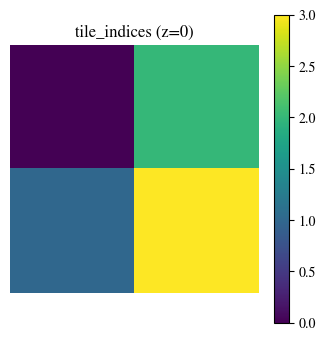

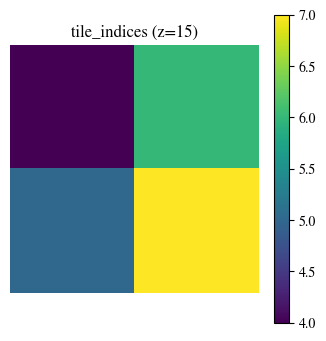

K = 8 | grid_shape = (32, 32, 16) | tile_shape = (2, 2, 2)


In [36]:
# =========================
# 0) Setup: one consistent test scene
# =========================
# Assumes you already have a working ManufacturingLoss object named `mfg`
# and Bounds class imported from your module.
# If not, stop here and import/create them first.

grid_shape = (32, 32, 16)
tile_shape = (2, 2, 2)
K = tile_shape[0] * tile_shape[1] * tile_shape[2]

tile_indices = make_tile_indices_equal_blocks(grid_shape, tile_shape)
show_tile_slice(tile_indices, z=0, title="tile_indices")
show_tile_slice(tile_indices, z=15, title="tile_indices")

# Density field: start uniform, then we will create masked variants for tests
rho_uniform = torch.full(grid_shape, 0.5, device=device, dtype=dtype)  # for ManufacturingLoss it is (X,Y,Z)
rho_uniform.requires_grad_(True)

# Tile parameters (raw, optimized variables)
P_raw = torch.nn.Parameter(torch.zeros(K, device=device, dtype=dtype))
v_raw = torch.nn.Parameter(torch.zeros(K, device=device, dtype=dtype))

# Shared printing parameters
material = "IN718"
h_mm = 0.11
t_mm = 0.04
d_req_um = 80.0
d_max_um = 200.0

print("K =", K, "| grid_shape =", grid_shape, "| tile_shape =", tile_shape)


In [35]:
import inspect

print("mfg exists:", "mfg" in globals())
if "mfg" in globals():
    print("mfg type:", type(mfg))
    print("mfg has sur:", hasattr(mfg, "sur"))
    print("mfg tile_shape:", getattr(mfg, "tile_shape", None))
    print("mfg tv_weight:", getattr(mfg, "tv_weight", None))

print("\nBounds exists:", "Bounds" in globals())
if "Bounds" in globals():
    print("Bounds:", Bounds)


mfg exists: True
mfg type: <class 'lpbf_to.losses.manufacturing_loss.ManufacturingLoss'>
mfg has sur: True
mfg tile_shape: (2, 2, 2)
mfg tv_weight: 0.05

Bounds exists: True
Bounds: <class 'lpbf_to.losses.manufacturing_loss.Bounds'>


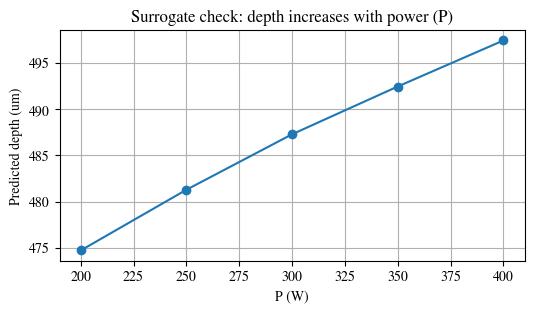

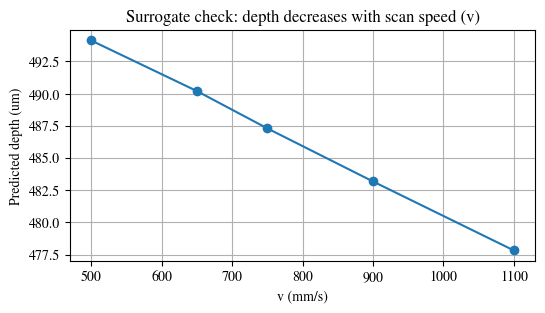

Monotonicity curves rendered.


In [37]:
# =========================
# 1) Surrogate monotonicity (visual): depth vs P and depth vs v
# =========================
# This checks the surrogate behaves physically:
# - increasing power should increase depth
# - increasing scan speed should decrease depth

# pick a mid-point operating condition from your bounds (or the typical values you used)
P0 = 300.0
v0 = 750.0

P_sweep = torch.tensor([200.0, 250.0, 300.0, 350.0, 400.0], device=device)
v_sweep = torch.tensor([500.0, 650.0, 750.0, 900.0, 1100.0], device=device)

# ManufacturingLoss uses bounded maps; here we directly call the surrogate inside mfg
# We can call the surrogate directly via mfg.sur (SurrogateInference) to isolate behavior.
mat_id = mfg._material_id(material)

with torch.no_grad():
    wP, dP = mfg.sur(P_sweep, torch.full_like(P_sweep, v0), h_mm, t_mm, mat_id)
    wv, dv = mfg.sur(torch.full_like(v_sweep, P0), v_sweep, h_mm, t_mm, mat_id)

plt.figure(figsize=(6,3))
plt.plot(P_sweep.cpu().numpy(), dP.cpu().numpy(), marker="o")
plt.title("Surrogate check: depth increases with power (P)")
plt.xlabel("P (W)")
plt.ylabel("Predicted depth (um)")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(v_sweep.cpu().numpy(), dv.cpu().numpy(), marker="o")
plt.title("Surrogate check: depth decreases with scan speed (v)")
plt.xlabel("v (mm/s)")
plt.ylabel("Predicted depth (um)")
plt.grid(True)
plt.show()

print("Monotonicity curves rendered.")


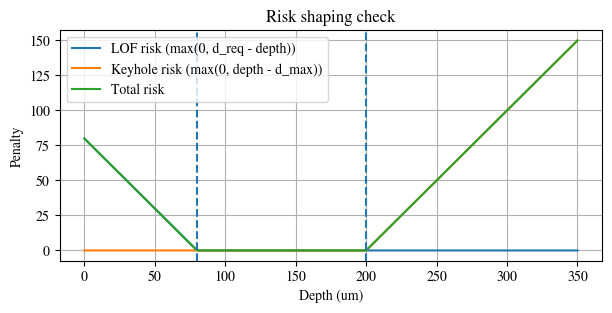

Risk curve rendered.


In [38]:
# =========================
# 2) Risk behavior (visual): LOF vs keyhole vs depth
# =========================
# This checks the risk logic is wired correctly:
# - LOF risk when depth < d_req
# - Keyhole risk when depth > d_max
# - Total risk = LOF + keyhole

depth_axis = torch.linspace(0.0, 350.0, 300, device=device)  # um range for a clear plot
d_req = torch.tensor(d_req_um, device=device)
d_max = torch.tensor(d_max_um, device=device)

lof = torch.relu(d_req - depth_axis)
key = torch.relu(depth_axis - d_max)
risk = lof + key

plt.figure(figsize=(7,3))
plt.plot(depth_axis.cpu().numpy(), lof.cpu().numpy(), label="LOF risk (max(0, d_req - depth))")
plt.plot(depth_axis.cpu().numpy(), key.cpu().numpy(), label="Keyhole risk (max(0, depth - d_max))")
plt.plot(depth_axis.cpu().numpy(), risk.cpu().numpy(), label="Total risk")
plt.axvline(d_req_um, linestyle="--")
plt.axvline(d_max_um, linestyle="--")
plt.title("Risk shaping check")
plt.xlabel("Depth (um)")
plt.ylabel("Penalty")
plt.legend()
plt.grid(True)
plt.show()

print("Risk curve rendered.")


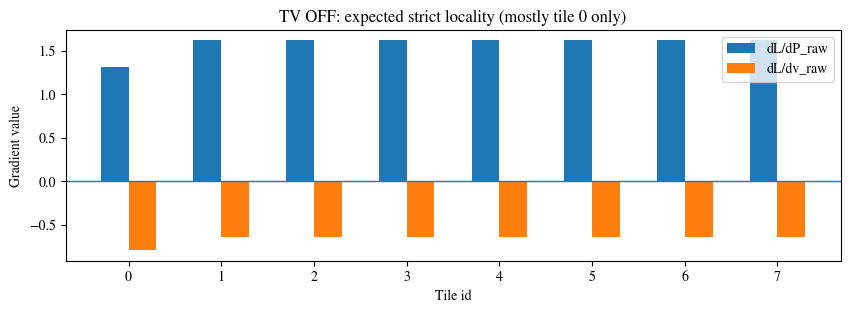

TV OFF | nonzero tiles P: [0, 1, 2, 3, 4, 5, 6, 7]
TV OFF | nonzero tiles v: [0, 1, 2, 3, 4, 5, 6, 7]


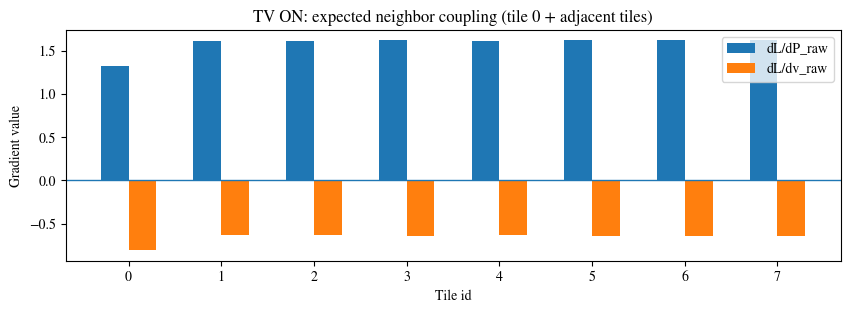

TV ON  | nonzero tiles P: [0, 1, 2, 3, 4, 5, 6, 7]
TV ON  | nonzero tiles v: [0, 1, 2, 3, 4, 5, 6, 7]


In [39]:
# =========================
# 3) Gradient locality (visual): TV OFF vs TV ON
# =========================
# Goal:
# - With TV OFF: only the activated tile should get gradients
# - With TV ON : activated tile + neighbors should get gradients (coupling)

tile_A = 0  # activate tile 0 by making only its raw params "different"
P_raw.data.zero_()
v_raw.data.zero_()
P_raw.data[tile_A] = 1.0   # any nonzero raw sets that tile away from others
v_raw.data[tile_A] = -1.0

# ---- TV OFF ----
mfg.tv_weight = 0.0
for p in [P_raw, v_raw]:
    if p.grad is not None:
        p.grad.zero_()
if rho_uniform.grad is not None:
    rho_uniform.grad.zero_()

out_off = mfg(
    rho=rho_uniform,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=d_req_um,
    d_max_um=d_max_um,
)
L_off = out_off["loss_total_mfg"]
L_off.backward()

gP_off = P_raw.grad.detach().clone()
gv_off = v_raw.grad.detach().clone()

plot_bar_grads(gP_off, gv_off, "TV OFF: expected strict locality (mostly tile 0 only)")
print("TV OFF | nonzero tiles P:", (gP_off.abs() > 1e-12).nonzero().flatten().tolist())
print("TV OFF | nonzero tiles v:", (gv_off.abs() > 1e-12).nonzero().flatten().tolist())

# ---- TV ON ----
mfg.tv_weight = 0.05
for p in [P_raw, v_raw]:
    p.grad.zero_()
if rho_uniform.grad is not None:
    rho_uniform.grad.zero_()

out_on = mfg(
    rho=rho_uniform,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=d_req_um,
    d_max_um=d_max_um,
)
L_on = out_on["loss_total_mfg"]
L_on.backward()

gP_on = P_raw.grad.detach().clone()
gv_on = v_raw.grad.detach().clone()

plot_bar_grads(gP_on, gv_on, "TV ON: expected neighbor coupling (tile 0 + adjacent tiles)")
print("TV ON  | nonzero tiles P:", (gP_on.abs() > 1e-12).nonzero().flatten().tolist())
print("TV ON  | nonzero tiles v:", (gv_on.abs() > 1e-12).nonzero().flatten().tolist())


Masked test loss_total_mfg: 262.2276916503906
Masked test mask_sum: 2049.433837890625


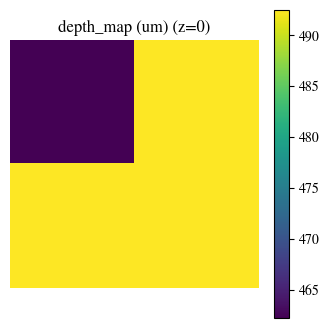

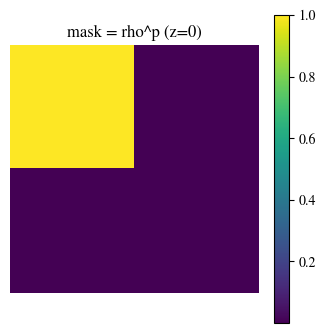

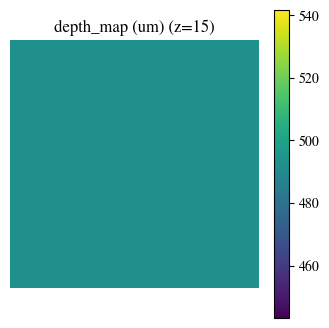

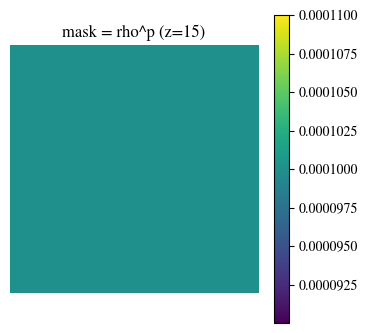

Masking visuals rendered.


In [40]:
# =========================
# 4) “Masking works” test (visual): move rho mass to one tile and see where loss focuses
# =========================
# Make rho high in tile 0, low elsewhere. This should make the masked reduction
# focus the risk on tile 0 region (because mask = rho^p).
rho_masked = torch.zeros(grid_shape, device=device, dtype=dtype)
rho_masked[tile_indices == 0] = 1.0
rho_masked[tile_indices != 0] = 0.1
rho_masked.requires_grad_(True)

mfg.tv_weight = 0.0
P_raw.data.zero_()
v_raw.data.zero_()

# Force tile 0 to be "worse" (e.g., lower depth) by pushing raw toward low power/high speed side.
# NOTE: sign depends on your bounding map; we just want "different" tile 0.
P_raw.data[0] = -2.0
v_raw.data[0] =  2.0

out_m = mfg(
    rho=rho_masked,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=d_req_um,
    d_max_um=d_max_um,
)
print("Masked test loss_total_mfg:", float(out_m["loss_total_mfg"]))
print("Masked test mask_sum:", float(out_m["mask_sum"]))

# Visualize depth map and (approx) where mask is strong, on two slices
# (depth_stats exists, but we want the full map; re-run by calling surrogate directly on maps)
with torch.no_grad():
    # reconstruct the actual P_map/v_map used by ManufacturingLoss
    b = mfg._get_bounds(material)
    P_tile = (b.P_min + (b.P_max - b.P_min) * torch.sigmoid(P_raw.detach()))
    v_tile = (b.v_min + (b.v_max - b.v_min) * torch.sigmoid(v_raw.detach()))
    P_map = P_tile[tile_indices]
    v_map = v_tile[tile_indices]
    width_map, depth_map = mfg.sur(P_map, v_map, h_mm, t_mm, mfg._material_id(material))
    mask_map = rho_masked.clamp(0,1).pow(mfg.rho_power)

show_scalar_slice(depth_map, z=0,  title="depth_map (um)")
show_scalar_slice(mask_map,  z=0,  title="mask = rho^p")
show_scalar_slice(depth_map, z=15, title="depth_map (um)")
show_scalar_slice(mask_map,  z=15, title="mask = rho^p")

print("Masking visuals rendered.")


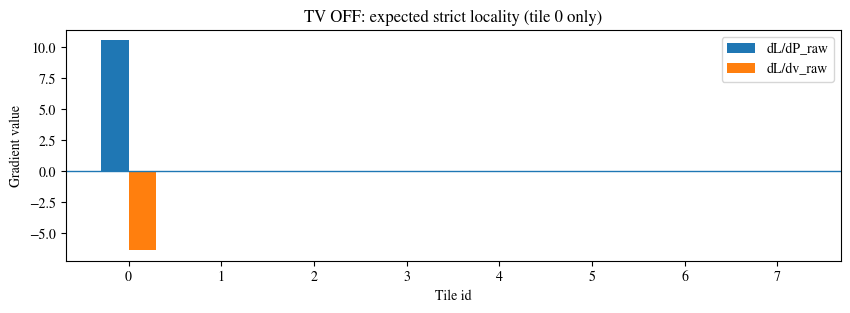

TV OFF | nonzero tiles P: [0]
TV OFF | nonzero tiles v: [0]


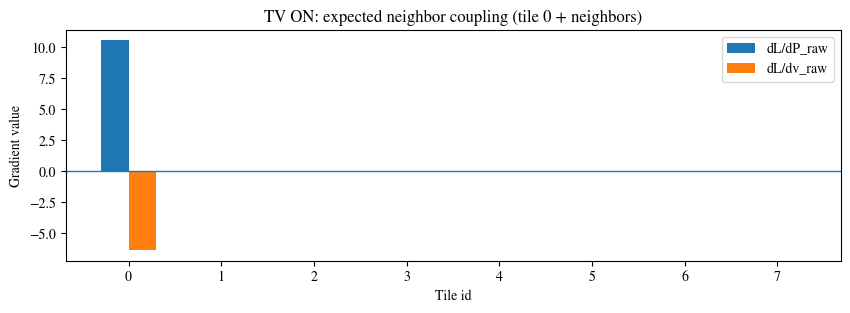

TV ON  | nonzero tiles P: [0, 1, 2, 4]
TV ON  | nonzero tiles v: [0, 1, 2, 4]


In [41]:
# =========================
# 3) Gradient locality (visual): TV OFF vs TV ON (CORRECTED)
# =========================

tile_A = 0

# Make tile_A the only active region in the loss
active_mask = (tile_indices == tile_A).to(dtype=torch.float32)

# Reset raw params: start all equal (0), then set tile_A different
with torch.no_grad():
    P_raw.zero_()
    v_raw.zero_()
    P_raw[tile_A] = 1.0
    v_raw[tile_A] = -1.0

def zero_grads():
    for p in [P_raw, v_raw]:
        if p.grad is not None:
            p.grad.zero_()
    if rho_uniform.grad is not None:
        rho_uniform.grad.zero_()

# ---- TV OFF ----
mfg.tv_weight = 0.0
zero_grads()

out_off = mfg(
    rho=rho_uniform,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=d_req_um,
    d_max_um=d_max_um,
    active_mask=active_mask,   # <-- KEY FIX
)
L_off = out_off["loss_total_mfg"]
L_off.backward()

gP_off = P_raw.grad.detach().clone()
gv_off = v_raw.grad.detach().clone()

plot_bar_grads(gP_off, gv_off, "TV OFF: expected strict locality (tile 0 only)")
print("TV OFF | nonzero tiles P:", (gP_off.abs() > 1e-12).nonzero().flatten().tolist())
print("TV OFF | nonzero tiles v:", (gv_off.abs() > 1e-12).nonzero().flatten().tolist())

# ---- TV ON ----
mfg.tv_weight = 0.05
zero_grads()

out_on = mfg(
    rho=rho_uniform,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=d_req_um,
    d_max_um=d_max_um,
    active_mask=active_mask,   # <-- KEY FIX
)
L_on = out_on["loss_total_mfg"]
L_on.backward()

gP_on = P_raw.grad.detach().clone()
gv_on = v_raw.grad.detach().clone()

plot_bar_grads(gP_on, gv_on, "TV ON: expected neighbor coupling (tile 0 + neighbors)")
print("TV ON  | nonzero tiles P:", (gP_on.abs() > 1e-12).nonzero().flatten().tolist())
print("TV ON  | nonzero tiles v:", (gv_on.abs() > 1e-12).nonzero().flatten().tolist())


TV OFF (risk disabled) nonzero P tiles: []
TV OFF (risk disabled) nonzero v tiles: []
TV OFF grads (P): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
TV OFF grads (v): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


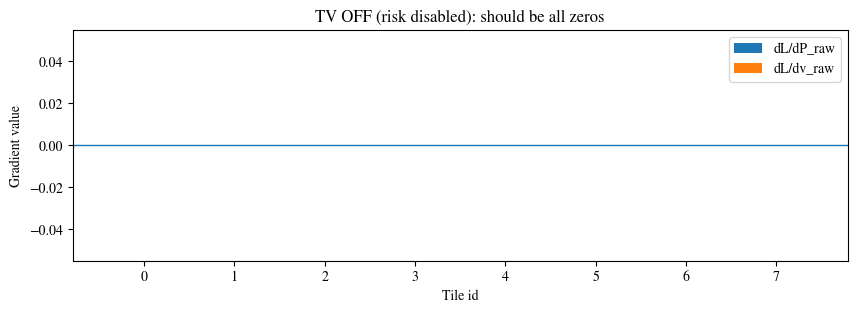


TV ON (risk disabled) nonzero P tiles: [0, 1, 2, 4]
TV ON (risk disabled) nonzero v tiles: [0, 1, 2, 4]
TV ON grads (P): [0.25, -0.08333300054073334, -0.08333300054073334, 0.0, -0.08333300054073334, 0.0, 0.0, 0.0]
TV ON grads (v): [-0.25, 0.08333300054073334, 0.08333300054073334, 0.0, 0.08333300054073334, 0.0, 0.0, 0.0]


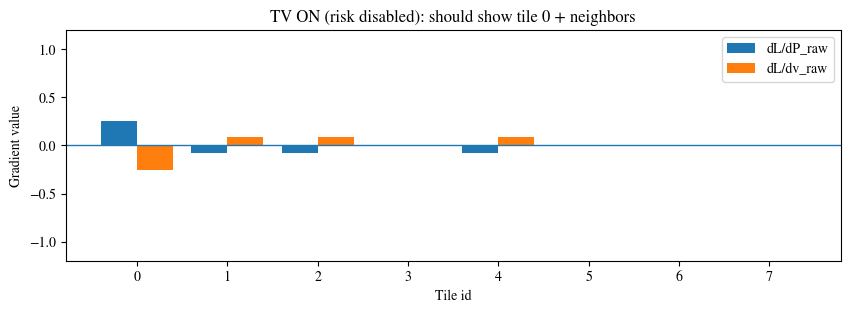

In [42]:
# =========================
# TV-only locality check (risk disabled)
# =========================
import torch
import matplotlib.pyplot as plt

# assumes: mfg, tile_indices, K, device already exist
material = "IN718"
h_mm = 0.11
t_mm = 0.04

# uniform rho (doesn't matter here because risk is disabled)
rho_uniform = torch.full(tile_indices.shape, 0.5, device=device, dtype=torch.float32)

# fresh raw params
P_raw_tv = torch.nn.Parameter(torch.zeros(K, device=device))
v_raw_tv = torch.nn.Parameter(torch.zeros(K, device=device))

tile_A = 0
with torch.no_grad():
    P_raw_tv.zero_(); v_raw_tv.zero_()
    P_raw_tv[tile_A] = 1.0
    v_raw_tv[tile_A] = -1.0

def plot_grads(gP, gv, title, ylim=None):
    x = torch.arange(len(gP)).cpu().numpy()
    gP = gP.detach().cpu().numpy()
    gv = gv.detach().cpu().numpy()
    plt.figure(figsize=(10,3))
    plt.bar(x - 0.2, gP, width=0.4, label="dL/dP_raw")
    plt.bar(x + 0.2, gv, width=0.4, label="dL/dv_raw")
    plt.axhline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Tile id")
    plt.ylabel("Gradient value")
    if ylim is not None:
        plt.ylim(*ylim)
    plt.legend()
    plt.show()

# --- 1) TV OFF => should be all zeros (since risk is disabled)
mfg.tv_weight = 0.0

for p in [P_raw_tv, v_raw_tv]:
    if p.grad is not None:
        p.grad.zero_()

# Disable risk by making LOF/keyhole always zero:
# depth is always between [-inf, +inf]
d_req_um = -1e9
d_max_um =  1e9

out0 = mfg(
    rho=rho_uniform,
    P_raw=P_raw_tv,
    v_raw=v_raw_tv,
    tile_indices=tile_indices,
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=d_req_um,
    d_max_um=d_max_um,
)
L0 = out0["loss_total_mfg"]
L0.backward()

gP0 = P_raw_tv.grad.detach().clone()
gv0 = v_raw_tv.grad.detach().clone()

print("TV OFF (risk disabled) nonzero P tiles:", (gP0.abs() > 1e-10).nonzero().flatten().tolist())
print("TV OFF (risk disabled) nonzero v tiles:", (gv0.abs() > 1e-10).nonzero().flatten().tolist())
print("TV OFF grads (P):", gP0.cpu().numpy().round(6).tolist())
print("TV OFF grads (v):", gv0.cpu().numpy().round(6).tolist())

plot_grads(gP0, gv0, "TV OFF (risk disabled): should be all zeros")

# --- 2) TV ON => should light up tile 0 + its neighbors (1,2,4) for (2,2,2)
mfg.tv_weight = 1.0  # make it large so it is clearly visible

for p in [P_raw_tv, v_raw_tv]:
    if p.grad is not None:
        p.grad.zero_()

out1 = mfg(
    rho=rho_uniform,
    P_raw=P_raw_tv,
    v_raw=v_raw_tv,
    tile_indices=tile_indices,
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=d_req_um,
    d_max_um=d_max_um,
)
L1 = out1["loss_total_mfg"]
L1.backward()

gP1 = P_raw_tv.grad.detach().clone()
gv1 = v_raw_tv.grad.detach().clone()

print("\nTV ON (risk disabled) nonzero P tiles:", (gP1.abs() > 1e-10).nonzero().flatten().tolist())
print("TV ON (risk disabled) nonzero v tiles:", (gv1.abs() > 1e-10).nonzero().flatten().tolist())
print("TV ON grads (P):", gP1.cpu().numpy().round(6).tolist())
print("TV ON grads (v):", gv1.cpu().numpy().round(6).tolist())

# zoom y-limits so small neighbor grads are visible
plot_grads(gP1, gv1, "TV ON (risk disabled): should show tile 0 + neighbors", ylim=(-1.2, 1.2))


device: cpu
tile_shape: (2, 2, 2) | K: 8
tile_indices shape: (32, 32, 16)
rho_masked stats (min/mean/max): 0.0 0.125 1.0
active voxels (tile_A): 2048
Using thresholds: d_req_um= 80.0 d_max_um= 200.0


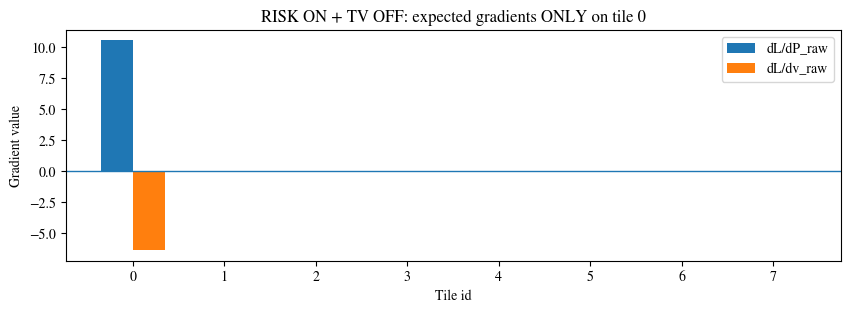

TV OFF | nonzero P tiles: [0]
TV OFF | nonzero v tiles: [0]
TV OFF | loss_total_mfg: 307.3642272949219


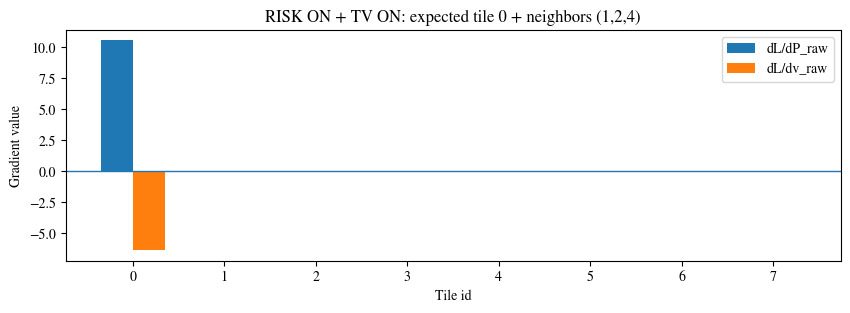

TV ON  | nonzero P tiles: [0, 1, 2, 4]
TV ON  | nonzero v tiles: [0, 1, 2, 4]
TV ON  | loss_total_mfg: 307.38922119140625
Expected neighbor tiles for tile 0 in (2,2,2): [1, 2, 4]


In [43]:
# =========================
# Smoke test: locality with RISK enabled
# Expectation:
#   TV OFF -> grads only on tile 0 (because rho is only nonzero in tile 0)
#   TV ON  -> grads on tile 0 + its neighbors (1,2,4 for a 2x2x2 grid with tile_A=0)
# =========================

import torch
import matplotlib.pyplot as plt

# ---- helpers ----
def plot_bar_grads(gP, gv, title):
    gP = gP.detach().cpu().numpy()
    gv = gv.detach().cpu().numpy()
    K = len(gP)
    x = list(range(K))
    w = 0.35
    plt.figure(figsize=(10,3))
    plt.bar([i - w/2 for i in x], gP, width=w, label="dL/dP_raw")
    plt.bar([i + w/2 for i in x], gv, width=w, label="dL/dv_raw")
    plt.axhline(0.0, linewidth=1)
    plt.xticks(x)
    plt.xlabel("Tile id")
    plt.ylabel("Gradient value")
    plt.title(title)
    plt.legend()
    plt.show()

def nonzero_tiles(g, thr=1e-12):
    return (g.abs() > thr).nonzero().flatten().tolist()

# ---- pre-checks (assumes these already exist from your previous cells) ----
assert "mfg" in globals(), "mfg not found (ManufacturingLoss object). Run your cell that creates mfg first."
assert "tile_indices" in globals(), "tile_indices not found. Run your tile_indices creation cell first."
assert "P_raw" in globals() and "v_raw" in globals(), "P_raw/v_raw not found. Run your cell that creates them first."

device = next(mfg.parameters()).device if len(list(mfg.parameters())) > 0 else torch.device("cpu")
tile_indices = tile_indices.to(device)

tile_shape = getattr(mfg, "tile_shape", (2,2,2))
K = tile_shape[0]*tile_shape[1]*tile_shape[2]
print("device:", device)
print("tile_shape:", tile_shape, "| K:", K)
print("tile_indices shape:", tuple(tile_indices.shape))

# ---- 1) Build rho_masked: density only inside tile_A ----
tile_A = 0
rho_masked = torch.zeros_like(tile_indices, dtype=torch.float32, device=device)  # (X,Y,Z)
rho_masked[tile_indices == tile_A] = 1.0                                         # only tile_A active
rho_masked.requires_grad_(False)

print("rho_masked stats (min/mean/max):",
      float(rho_masked.min()), float(rho_masked.mean()), float(rho_masked.max()))
print("active voxels (tile_A):", int((tile_indices == tile_A).sum().item()))

# ---- 2) Activate only tile_A in raw params (others 0) ----
with torch.no_grad():
    P_raw.data.zero_()
    v_raw.data.zero_()
    P_raw.data[tile_A] = 1.0
    v_raw.data[tile_A] = -1.0

# ---- 3) Choose risk thresholds so risk is definitely ON ----
# Your surrogate depths are ~480-505 um for typical P/v/h/t
# So force KEYHOLE to be active by setting d_max low (e.g., 200 um)
material = "IN718"
h_mm = 0.11
t_mm = 0.04
d_req_um = 80.0
d_max_um = 200.0  # intentionally low so keyhole_map > 0 almost everywhere

print("Using thresholds:", "d_req_um=", d_req_um, "d_max_um=", d_max_um)

# ---- 4) TV OFF ----
mfg.tv_weight = 0.0
for p in [P_raw, v_raw]:
    if p.grad is not None:
        p.grad.zero_()

out_off = mfg(
    rho=rho_masked,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=d_req_um,
    d_max_um=d_max_um,
)
L_off = out_off["loss_total_mfg"]
L_off.backward()

gP_off = P_raw.grad.detach().clone()
gv_off = v_raw.grad.detach().clone()

plot_bar_grads(gP_off, gv_off, "RISK ON + TV OFF: expected gradients ONLY on tile 0")
print("TV OFF | nonzero P tiles:", nonzero_tiles(gP_off))
print("TV OFF | nonzero v tiles:", nonzero_tiles(gv_off))
print("TV OFF | loss_total_mfg:", float(L_off))

# ---- 5) TV ON ----
mfg.tv_weight = 0.05
for p in [P_raw, v_raw]:
    if p.grad is not None:
        p.grad.zero_()

out_on = mfg(
    rho=rho_masked,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=d_req_um,
    d_max_um=d_max_um,
)
L_on = out_on["loss_total_mfg"]
L_on.backward()

gP_on = P_raw.grad.detach().clone()
gv_on = v_raw.grad.detach().clone()

plot_bar_grads(gP_on, gv_on, "RISK ON + TV ON: expected tile 0 + neighbors (1,2,4)")
print("TV ON  | nonzero P tiles:", nonzero_tiles(gP_on))
print("TV ON  | nonzero v tiles:", nonzero_tiles(gv_on))
print("TV ON  | loss_total_mfg:", float(L_on))

# ---- 6) Print neighbor expectation for tile 0 (2x2x2) ----
if tile_shape == (2,2,2) and tile_A == 0:
    print("Expected neighbor tiles for tile 0 in (2,2,2): [1, 2, 4]")


Expected neighbor tiles for tile 0 in (2,2,2): [1, 2, 4]

RISK ON + TV OFF
loss_total_mfg: 294.3305358886719
nonzero P tiles: [0, 1, 2, 3, 4, 5, 6, 7]
nonzero v tiles: [0, 1, 2, 3, 4, 5, 6, 7]
gP: [1.3153823614120483, 1.6172066926956177, 1.6172066926956177, 1.6172066926956177, 1.6172066926956177, 1.6172066926956177, 1.6172066926956177, 1.6172066926956177]
gv: [-0.7957869172096252, -0.6372795701026917, -0.6372795701026917, -0.6372795701026917, -0.6372795701026917, -0.6372795701026917, -0.6372795701026917, -0.6372795701026917]


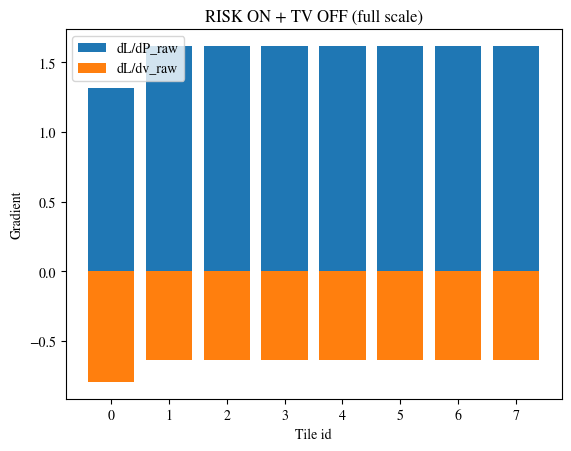

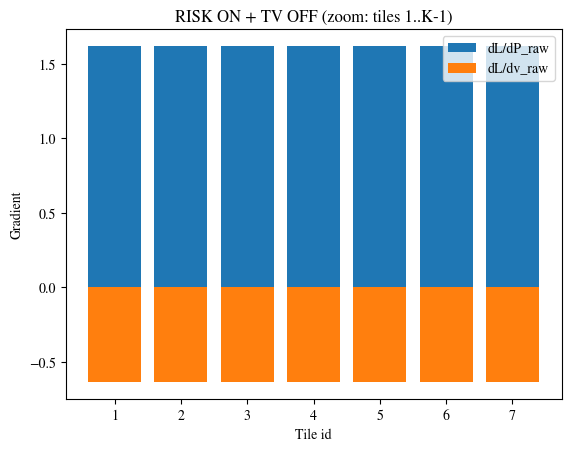


RISK ON + TV ON
loss_total_mfg: 294.35552978515625
nonzero P tiles: [0, 1, 2, 3, 4, 5, 6, 7]
nonzero v tiles: [0, 1, 2, 3, 4, 5, 6, 7]
gP: [1.3278825283050537, 1.6130399703979492, 1.6130399703979492, 1.6172066926956177, 1.6130399703979492, 1.6172066926956177, 1.6172066926956177, 1.6172066926956177]
gv: [-0.8082869052886963, -0.633112907409668, -0.633112907409668, -0.6372795701026917, -0.633112907409668, -0.6372795701026917, -0.6372795701026917, -0.6372795701026917]


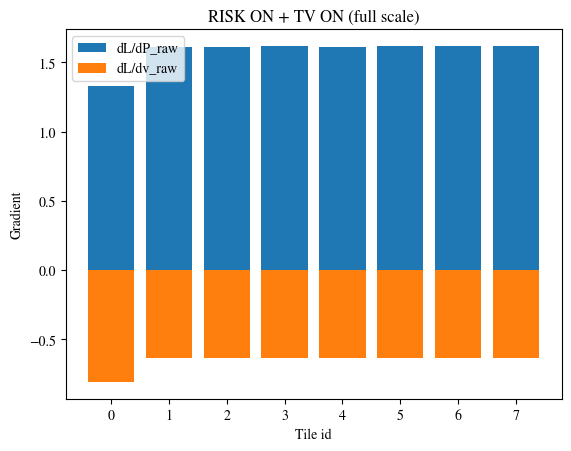

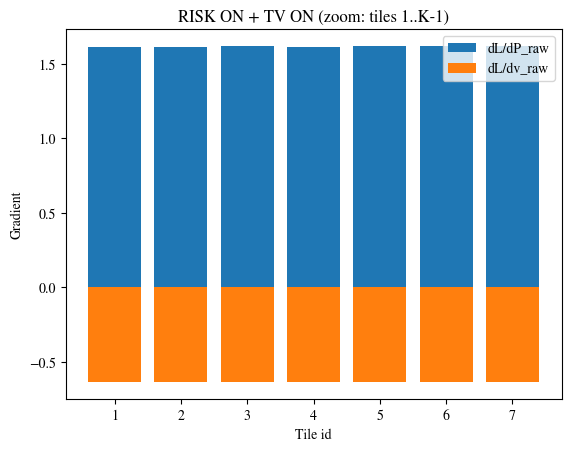


RISK OFF + TV ON (pure TV coupling)
loss_total_mfg: 0.02500000037252903
nonzero P tiles: [0, 1, 2, 4]
nonzero v tiles: [0, 1, 2, 4]
gP: [0.01250000111758709, -0.004166666883975267, -0.004166666883975267, 0.0, -0.004166666883975267, 0.0, 0.0, 0.0]
gv: [-0.01250000111758709, 0.004166666883975267, 0.004166666883975267, 0.0, 0.004166666883975267, 0.0, 0.0, 0.0]


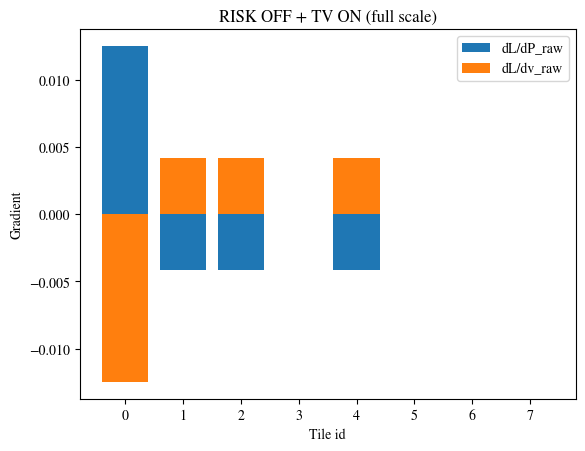

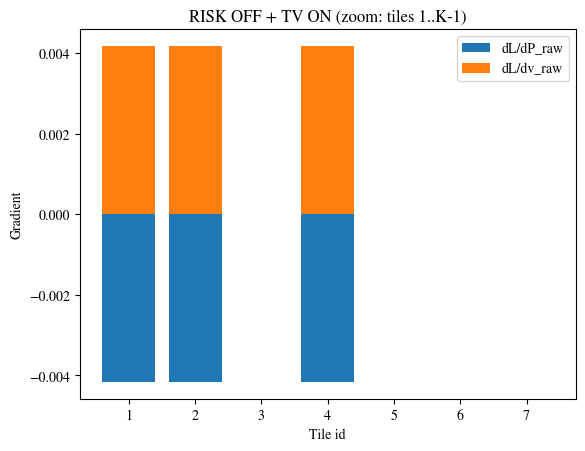

In [44]:
import torch
import matplotlib.pyplot as plt

def neighbor_tiles_2x2x2(tile_id):
    # For tile_shape=(2,2,2): neighbors of 0 are [1,2,4]
    # General formula for 2x2x2:
    # id = ix + 2*(iy + 2*iz)
    ix = tile_id % 2
    iy = (tile_id // 2) % 2
    iz = tile_id // 4
    neigh = []
    def tid(ix,iy,iz): return ix + 2*(iy + 2*iz)
    if ix+1 < 2: neigh.append(tid(ix+1,iy,iz))
    if ix-1 >= 0: neigh.append(tid(ix-1,iy,iz))
    if iy+1 < 2: neigh.append(tid(ix,iy+1,iz))
    if iy-1 >= 0: neigh.append(tid(ix,iy-1,iz))
    if iz+1 < 2: neigh.append(tid(ix,iy,iz+1))
    if iz-1 >= 0: neigh.append(tid(ix,iy,iz-1))
    return sorted(set(neigh))

def plot_grads_two_scales(gP, gv, title):
    K = gP.numel()
    x = list(range(K))

    # Full scale plot
    plt.figure()
    plt.bar(x, gP.detach().cpu().numpy(), label="dL/dP_raw")
    plt.bar(x, gv.detach().cpu().numpy(), label="dL/dv_raw")
    plt.title(title + " (full scale)")
    plt.xlabel("Tile id")
    plt.ylabel("Gradient")
    plt.legend()
    plt.show()

    # Zoomed plot: exclude tile 0 to see neighbors
    plt.figure()
    x2 = x[1:]
    plt.bar(x2, gP[1:].detach().cpu().numpy(), label="dL/dP_raw")
    plt.bar(x2, gv[1:].detach().cpu().numpy(), label="dL/dv_raw")
    plt.title(title + " (zoom: tiles 1..K-1)")
    plt.xlabel("Tile id")
    plt.ylabel("Gradient")
    plt.legend()
    plt.show()

# -------------------------
# Run comparison
# -------------------------
tile_A = 0
material = "IN718"
h_mm = 0.11
t_mm = 0.04
d_req_um = 80.0
d_max_um = 200.0

# Ensure clean grads
P_raw.data.zero_()
v_raw.data.zero_()
P_raw.data[tile_A] = 1.0
v_raw.data[tile_A] = -1.0

expected_neighbors = neighbor_tiles_2x2x2(tile_A)
print("Expected neighbor tiles for tile 0 in (2,2,2):", expected_neighbors)

def run_case(tv_weight, risk_on=True):
    mfg.tv_weight = tv_weight

    # If you want "risk disabled", set thresholds wide so risk=0
    if not risk_on:
        _d_req, _d_max = -1e9, 1e9
    else:
        _d_req, _d_max = d_req_um, d_max_um

    for p in [P_raw, v_raw]:
        if p.grad is not None:
            p.grad.zero_()

    out = mfg(
        rho=rho_uniform,
        P_raw=P_raw,
        v_raw=v_raw,
        tile_indices=tile_indices,
        material=material,
        h_mm=h_mm,
        t_mm=t_mm,
        d_req_um=_d_req,
        d_max_um=_d_max,
    )
    L = out["loss_total_mfg"]
    L.backward()
    gP = P_raw.grad.detach().clone()
    gv = v_raw.grad.detach().clone()
    return float(L.detach()), gP, gv

# Case 1: RISK ON + TV OFF
L1, gP1, gv1 = run_case(tv_weight=0.0, risk_on=True)
print("\nRISK ON + TV OFF")
print("loss_total_mfg:", L1)
print("nonzero P tiles:", (gP1.abs() > 1e-10).nonzero().flatten().tolist())
print("nonzero v tiles:", (gv1.abs() > 1e-10).nonzero().flatten().tolist())
print("gP:", gP1.cpu().numpy().tolist())
print("gv:", gv1.cpu().numpy().tolist())
plot_grads_two_scales(gP1, gv1, "RISK ON + TV OFF")

# Case 2: RISK ON + TV ON
L2, gP2, gv2 = run_case(tv_weight=0.05, risk_on=True)
print("\nRISK ON + TV ON")
print("loss_total_mfg:", L2)
print("nonzero P tiles:", (gP2.abs() > 1e-10).nonzero().flatten().tolist())
print("nonzero v tiles:", (gv2.abs() > 1e-10).nonzero().flatten().tolist())
print("gP:", gP2.cpu().numpy().tolist())
print("gv:", gv2.cpu().numpy().tolist())
plot_grads_two_scales(gP2, gv2, "RISK ON + TV ON")

# Case 3: RISK OFF + TV ON (pure TV coupling visibility)
L3, gP3, gv3 = run_case(tv_weight=0.05, risk_on=False)
print("\nRISK OFF + TV ON (pure TV coupling)")
print("loss_total_mfg:", L3)
print("nonzero P tiles:", (gP3.abs() > 1e-10).nonzero().flatten().tolist())
print("nonzero v tiles:", (gv3.abs() > 1e-10).nonzero().flatten().tolist())
print("gP:", gP3.cpu().numpy().tolist())
print("gv:", gv3.cpu().numpy().tolist())
plot_grads_two_scales(gP3, gv3, "RISK OFF + TV ON")


Baseline depth mean: 492.4687194824219
Using tight window d_req, d_max: 491.4687194824219 493.4687194824219

RISK locality + TV OFF (expect ONLY tile 0)
loss_total_mfg: 1.7369346618652344
nonzero P tiles: [0]
nonzero v tiles: [0]


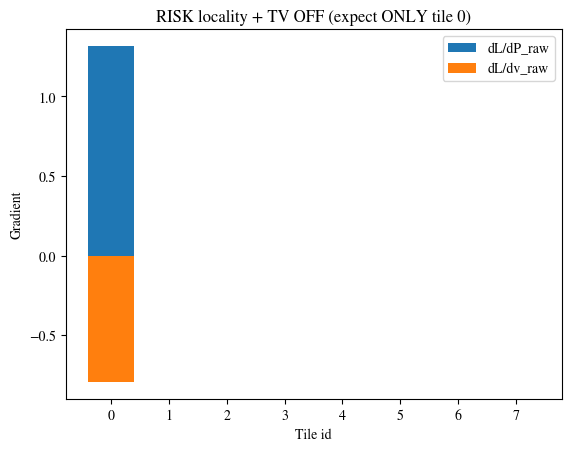


RISK locality + TV ON (expect tile 0 + neighbors)
loss_total_mfg: 1.7619346380233765
nonzero P tiles: [0, 1, 2, 4]
nonzero v tiles: [0, 1, 2, 4]


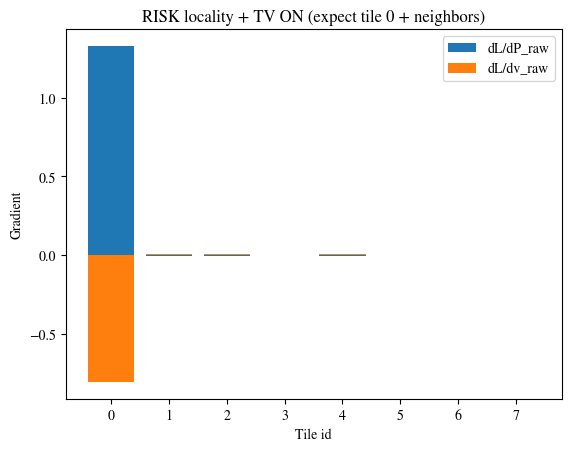

In [45]:
# =========================
# Risk locality test: make ONLY tile 0 violate the depth window
# =========================

import torch
import matplotlib.pyplot as plt

# assumes: mfg, tile_indices, rho_uniform, P_raw, v_raw already exist
device = rho_uniform.device
K = int(tile_indices.max().item() + 1)

material = "IN718"
h_mm, t_mm = 0.11, 0.04

# 1) Baseline: all tiles identical (raw=0)
with torch.no_grad():
    P_raw.zero_()
    v_raw.zero_()

out_base = mfg(
    rho=rho_uniform,
    P_raw=P_raw,
    v_raw=v_raw,
    tile_indices=tile_indices,
    material=material,
    h_mm=h_mm,
    t_mm=t_mm,
    d_req_um=80.0,     # temporary, will override below
    d_max_um=200.0,
)

# baseline depth mean (this is what "normal" tiles produce)
d0 = float(out_base["depth_stats"][1].item())

# choose a *tight* safe window around baseline so baseline risk ~ 0
d_req = d0 - 1.0
d_max = d0 + 1.0

print("Baseline depth mean:", d0)
print("Using tight window d_req, d_max:", d_req, d_max)

# 2) Now perturb ONLY tile 0 so it violates (push depth outside the window)
tile_A = 0
with torch.no_grad():
    P_raw.zero_()
    v_raw.zero_()
    P_raw[tile_A] = 1.0
    v_raw[tile_A] = -1.0

def run_case(tv_weight: float, title: str):
    mfg.tv_weight = tv_weight

    for p in [P_raw, v_raw]:
        if p.grad is not None:
            p.grad.zero_()

    out = mfg(
        rho=rho_uniform,
        P_raw=P_raw,
        v_raw=v_raw,
        tile_indices=tile_indices,
        material=material,
        h_mm=h_mm,
        t_mm=t_mm,
        d_req_um=d_req,
        d_max_um=d_max,
    )
    L = out["loss_total_mfg"]
    L.backward()

    gP = P_raw.grad.detach().cpu()
    gv = v_raw.grad.detach().cpu()

    nzP = (gP.abs() > 1e-10).nonzero().flatten().tolist()
    nzv = (gv.abs() > 1e-10).nonzero().flatten().tolist()

    print("\n" + title)
    print("loss_total_mfg:", float(L))
    print("nonzero P tiles:", nzP)
    print("nonzero v tiles:", nzv)

    # bar plot
    x = list(range(K))
    plt.figure()
    plt.bar(x, gP.numpy(), label="dL/dP_raw")
    plt.bar(x, gv.numpy(), label="dL/dv_raw")
    plt.title(title)
    plt.xlabel("Tile id")
    plt.ylabel("Gradient")
    plt.legend()
    plt.show()

# 3) Expectation:
# - TV OFF: gradients only on tile 0 (risk locality)
# - TV ON : gradients on tile 0 + neighbors (TV coupling)
run_case(tv_weight=0.0,  title="RISK locality + TV OFF (expect ONLY tile 0)")
run_case(tv_weight=0.05, title="RISK locality + TV ON (expect tile 0 + neighbors)")


In [46]:
import inspect
import dl4to
from dl4to import topo_solvers, criteria

print("dl4to imported")
print("topo_solvers members:", [x for x in dir(topo_solvers) if "SIMP" in x or "Topo" in x or "Solver" in x])

# SIMP class (if present)
if hasattr(topo_solvers, "SIMP"):
    SIMP = topo_solvers.SIMP
    print("\nSIMP found:", SIMP)
    print("SIMP.__init__ sig:", inspect.signature(SIMP.__init__))
    # common call patterns
    if hasattr(SIMP, "__call__"):
        print("SIMP.__call__ sig:", inspect.signature(SIMP.__call__))

# Criteria available
print("\ncriteria members (partial):", [x for x in dir(criteria) if x.lower() in ("compliance","volumepenalty","volume","criterion","weightedcriterion","combinedcriterion")])


dl4to imported
topo_solvers members: ['OracleSolver', 'SIMP', 'SIMPIterator', 'TopoSolver', 'TrainableTopoSolver', 'TrivialSolver']

SIMP found: <class 'dl4to.topo_solvers.SIMP'>
SIMP.__init__ sig: (self, criterion: 'dl4to.criteria.Criterion', p: float = 3.0, n_iterations: int = 50, verbose: bool = True, lr: float = 0.03, binarizer_steepening_factor: float = 1.0, density_representer: 'dl4to.density_representers.DensityRepresenter' = FilteringDensityRepresenter(), return_intermediate_solutions: bool = False)
SIMP.__call__ sig: (self, problems_or_solutions: list, eval_mode: bool = True)

criteria members (partial): ['CombinedCriterion', 'Compliance', 'Criterion', 'Volume', 'WeightedCriterion']


In [48]:
import inspect
from dl4to.criteria import Volume

print("Volume.__init__ sig:", inspect.signature(Volume.__init__))
print("Volume.__call__ sig:", inspect.signature(Volume.__call__))


Volume.__init__ sig: (self, compute_only_on_design_space: bool = False)
Volume.__call__ sig: (self, solutions: list, gt_solutions: list = None, binary: bool = False)


In [52]:

import torch
from dl4to.criteria import Compliance, Volume, WeightedCriterion, CombinedCriterion

# ---- settings ----
vol_frac = 0.25
lambda_vol = 1.0

# ---- base DL4TO criteria ----
C = Compliance(problem)
V = Volume()

class VolumePenaltyWrapper:
    """
    DL4TO-compatible criterion wrapper.
    Penalty = lambda_vol * (mean_volume_fraction - vol_frac)^2
    """
    def __init__(self, Vcrit, vol_frac: float, lambda_vol: float = 1.0):
        self.Vcrit = Vcrit
        self.vol_frac = float(vol_frac)
        self.lambda_vol = float(lambda_vol)

        # Required by CombinedCriterion
        self.name = f"volpen_{self.vol_frac}"
        self.supervised = False
        self.differentiable = False

        # Both Compliance and a penalty should be minimized
        self.lower_is_better = True

    def __call__(self, solutions, gt_solutions=None, binary: bool = False):
        v = self.Vcrit(solutions, gt_solutions=gt_solutions, binary=binary).mean()
        return self.lambda_vol * (v - self.vol_frac) ** 2

Vpen = VolumePenaltyWrapper(V, vol_frac=vol_frac, lambda_vol=lambda_vol)

# Combine pairwise (DL4TO expects criterion1, criterion2)
J = CombinedCriterion(WeightedCriterion(C, 1.0), Vpen)

print("Built combined criterion J =", J.name)
print("vol_frac =", vol_frac, "| lambda_vol =", lambda_vol)
print("J.lower_is_better =", J.lower_is_better)


Built combined criterion J = 1.0_compliance_plus_volpen_0.25
vol_frac = 0.25 | lambda_vol = 1.0
J.lower_is_better = True


In [56]:
import torch
from dl4to.criteria import Compliance, Volume, WeightedCriterion, CombinedCriterion
from dl4to.solution import Solution

# ----------------------------
# 1) Build DL4TO-native criteria correctly (NO problem passed in)
# ----------------------------
C = Compliance()      # <-- IMPORTANT: no args
V = Volume()          # <-- IMPORTANT: no args

# ----------------------------
# 2) Volume penalty wrapper that is compatible with CombinedCriterion
# ----------------------------
class VolumePenaltyWrapper:
    def __init__(self, volume_criterion, vol_frac: float, lambda_vol: float = 1.0):
        self.volume_criterion = volume_criterion
        self.vol_frac = float(vol_frac)
        self.lambda_vol = float(lambda_vol)

        # Required by CombinedCriterion
        self.name = f"volpen_{self.vol_frac}"
        self.lower_is_better = True
        self.supervised = False
        self.differentiable = False  # DL4TO volume is not autograd-based

    def __call__(self, solutions, gt_solutions=None, binary=False):
        # Volume returns a tensor per-solution; reduce to scalar for penalty
        v = self.volume_criterion(solutions, gt_solutions=gt_solutions, binary=binary).mean()
        return self.lambda_vol * (v - self.vol_frac) ** 2

# Settings
vol_frac = 0.25
lambda_vol = 1.0

Vpen = VolumePenaltyWrapper(V, vol_frac=vol_frac, lambda_vol=lambda_vol)

# Combine: J = 1.0*Compliance + VolumePenalty
J = CombinedCriterion(WeightedCriterion(C, 1.0), Vpen)

print("Built combined criterion J =", J.name)
print("J.lower_is_better =", J.lower_is_better)

# ----------------------------
# 3) Sanity check evaluation on a valid Solution
# ----------------------------
device = problem.device
dtype  = problem.dtype
rho0 = torch.full((1, *problem.shape), vol_frac, device=device, dtype=dtype)

sol0 = Solution(problem=problem, θ=rho0)

valC = C([sol0]).mean()
valV = V([sol0]).mean()
valP = Vpen([sol0])
valJ = J([sol0]).mean()

print("\nSanity check on uniform rho:")
print("Compliance:", float(valC))
print("Volume fraction:", float(valV))
print("Volume penalty:", float(valP))
print("Combined J:", float(valJ))


Built combined criterion J = 1.0_compliance_plus_volpen_0.25
J.lower_is_better = True

Sanity check on uniform rho:
Compliance: 6.151138373709703e-19
Volume fraction: 16384.0
Volume penalty: 268427264.0
Combined J: 268427264.0


In [55]:
import torch
from dl4to.solution import Solution

nx, ny, nz = problem.shape  # torch.Size([32,32,16])

# IMPORTANT: use (X,Y,Z) for theta in this DL4TO version
theta0 = torch.full((nx, ny, nz), vol_frac, device=problem.device, dtype=problem.dtype)

sol0 = Solution(problem=problem, θ=theta0)

valC = C([sol0]).mean()
valV = V([sol0]).mean()
valP = Vpen([sol0])
valJ = J([sol0]).mean()

print("theta0.shape:", tuple(theta0.shape))
print("Compliance:", float(valC))
print("Volume (should be ~vol_frac):", float(valV))
print("Volume penalty:", float(valP))
print("Combined J:", float(valJ))


theta0.shape: (32, 32, 16)
Compliance: 6.151138373709703e-19
Volume (should be ~vol_frac): 16384.0
Volume penalty: 268427264.0
Combined J: 268427264.0


In [57]:
import torch
from dl4to.criteria import Compliance, CombinedCriterion, WeightedCriterion
from dl4to.solution import Solution

# ---------- helpers ----------
def _get_theta(sol):
    # DL4TO uses θ in code, but in python it might be stored as "θ" or "theta"
    if hasattr(sol, "θ"):
        return getattr(sol, "θ")
    if hasattr(sol, "theta"):
        return getattr(sol, "theta")
    raise AttributeError("Solution has no θ/theta attribute")

class VolumeFracPenaltyCriterion:
    """
    Returns a scalar penalty (lower is better):
        lambda_vol * (vol_frac(theta) - target)^2
    Compatible with DL4TO CombinedCriterion checks.
    """
    def __init__(self, target: float, lambda_vol: float = 1.0, name: str | None = None):
        self.target = float(target)
        self.lambda_vol = float(lambda_vol)
        self.name = name or f"volpen_{self.target}"
        self.lower_is_better = True
        self.supervised = False
        self.differentiable = True

    def __call__(self, solutions: list, gt_solutions: list = None, binary: bool = False):
        vals = []
        for sol in solutions:
            theta = _get_theta(sol)
            # enforce (1,nx,ny,nz)
            if theta.ndim == 3:
                theta = theta.unsqueeze(0)

            Omega = sol.problem.Ω_design
            if Omega.ndim == 3:
                Omega = Omega.unsqueeze(0)
            Omega = Omega.to(dtype=theta.dtype, device=theta.device)

            # volume fraction in design space
            vf = (theta * Omega).sum() / (Omega.sum() + 1e-12)

            penalty = self.lambda_vol * (vf - self.target) ** 2
            vals.append(penalty)

        return torch.stack(vals)

# ---------- build criteria correctly ----------
# IMPORTANT: In your DL4TO version, Compliance(...) should NOT be called with `problem`.
# Use default Compliance() (or check signature if you want).
C = Compliance()

vol_frac = 0.25
lambda_vol = 1.0
Vpen = VolumeFracPenaltyCriterion(target=vol_frac, lambda_vol=lambda_vol)

J = CombinedCriterion(WeightedCriterion(C, 1.0), Vpen)

print("Built J:", J.name)
print("J.lower_is_better:", J.lower_is_better)

# ---------- sanity test on uniform theta ----------
theta0 = torch.full((1, *problem.shape), vol_frac, device=problem.device, dtype=problem.dtype)
sol0 = Solution(problem=problem, θ=theta0)

# compute vf directly (should be ~vol_frac)
Omega = problem.Ω_design.to(dtype=theta0.dtype, device=theta0.device)
vf_direct = (theta0 * Omega).sum() / (Omega.sum() + 1e-12)

pen = Vpen([sol0]).item()

print("\nSanity check:")
print("theta0.shape:", tuple(theta0.shape))
print("vf_direct (expect ~0.25):", float(vf_direct))
print("vol_penalty:", pen)


Built J: 1.0_compliance_plus_volpen_0.25
J.lower_is_better: True

Sanity check:
theta0.shape: (1, 32, 32, 16)
vf_direct (expect ~0.25): 0.25
vol_penalty: 0.5625


In [58]:
import torch

# Confirm the criterion settings
print("Vpen.target =", Vpen.target)
print("Vpen.lambda_vol =", Vpen.lambda_vol)

# Recompute exactly as Vpen does (inline)
theta = sol0.θ
if theta.ndim == 3:
    theta = theta.unsqueeze(0)

Omega = sol0.problem.Ω_design
if Omega.ndim == 3:
    Omega = Omega.unsqueeze(0)

Omega = Omega.to(dtype=theta.dtype, device=theta.device)

vf_vpen = (theta * Omega).sum() / (Omega.sum() + 1e-12)
diff = vf_vpen - Vpen.target
pen_manual = Vpen.lambda_vol * diff**2

print("\nInside-Vpen recompute:")
print("theta shape:", tuple(theta.shape))
print("Omega shape:", tuple(Omega.shape))
print("Omega sum:", float(Omega.sum()))
print("vf_vpen:", float(vf_vpen))
print("diff (vf-target):", float(diff))
print("pen_manual:", float(pen_manual))

# Compare with calling Vpen
pen_call = Vpen([sol0]).item()
print("\nVpen([sol0]) returned:", pen_call)


Vpen.target = 0.25
Vpen.lambda_vol = 1.0

Inside-Vpen recompute:
theta shape: (1, 32, 32, 16)
Omega shape: (1, 32, 32, 16)
Omega sum: 16384.0
vf_vpen: 1.0
diff (vf-target): 0.75
pen_manual: 0.5625

Vpen([sol0]) returned: 0.5625


In [59]:
import torch

print("theta0 stats (what you constructed):",
      float(theta0.min()), float(theta0.mean()), float(theta0.max()),
      "shape", tuple(theta0.shape))

th = sol0.θ
print("sol0.θ stats (what criteria see):",
      float(th.min()), float(th.mean()), float(th.max()),
      "shape", tuple(th.shape), "dtype", th.dtype)

# Compare values directly
# (broadcast theta0 if needed)
theta0_cmp = theta0
if theta0_cmp.ndim == 3:
    theta0_cmp = theta0_cmp.unsqueeze(0)

diff = (th - theta0_cmp.to(th.device, th.dtype)).abs()
print("abs diff stats (sol0.θ - theta0):",
      float(diff.min()), float(diff.mean()), float(diff.max()))


theta0 stats (what you constructed): 0.25 0.25 0.25 shape (1, 32, 32, 16)
sol0.θ stats (what criteria see): 1.0 1.0 1.0 shape (1, 32, 32, 16) dtype torch.float32
abs diff stats (sol0.θ - theta0): 0.75 0.75 0.75


In [60]:
# Discover which Solution attribute still contains the original density values
attrs = [a for a in dir(sol0) if ("theta" in a.lower() or "θ" in a.lower() or "dens" in a.lower()) and not a.startswith("_")]
print("Candidate density attrs:", attrs)

for a in attrs:
    try:
        x = getattr(sol0, a)
        if torch.is_tensor(x):
            print(f"{a}: shape={tuple(x.shape)} min/mean/max={float(x.min())}/{float(x.mean())}/{float(x.max())}")
    except Exception as e:
        print(f"{a}: error {repr(e)}")


Candidate density attrs: ['enforce_θ_on_Ω_design', 'get_θ', 'θ']
θ: shape=(1, 32, 32, 16) min/mean/max=1.0/1.0/1.0


In [61]:
import torch
from dl4to.pde import FDM
from dl4to.problem import Problem

# ---- grid ----
nx, ny, nz = 32, 32, 16
device = "cpu"
dtype = torch.float32

# ---- material constants (placeholders; keep consistent with your earlier cell) ----
E = 210e3
nu = 0.30
sigma_ys = 500.0
h = 1.0

# ---- Dirichlet BC mask: shape (3, nx, ny, nz) boolean ----
Ω_dirichlet = torch.zeros((3, nx, ny, nz), dtype=torch.bool, device=device)
# Example: clamp x=0 face (all components fixed)
Ω_dirichlet[:, 0, :, :] = True

# ---- Force field: shape (3, nx, ny, nz) float ----
F = torch.zeros((3, nx, ny, nz), dtype=dtype, device=device)
# Example: downward force on a small patch at x=nx-1 face
F[1, nx-1, ny//2-1:ny//2+1, nz//2-2:nz//2+2] = -1.0

# ---- Ω_design: IMPORTANT ----
# 0 = designable (free)
# 1 = density is enforced to solid (restricted)
Ω_design = torch.zeros((1, nx, ny, nz), dtype=dtype, device=device)

# Option A (recommended minimum): enforce solid where force is applied
F_mask = (F != 0).sum(dim=0, keepdim=True).bool()   # shape (1,nx,ny,nz)
Ω_design[F_mask] = 1.0

# (Optional) enforce solid also at the clamped face (often helps stability)
Ω_design[:, 0, :, :] = 1.0

# ---- PDE solver + Problem ----
pde_solver = FDM()

problem = Problem(
    E=E,
    ν=nu,
    σ_ys=sigma_ys,
    h=h,
    Ω_dirichlet=Ω_dirichlet,
    Ω_design=Ω_design,
    F=F,
    pde_solver=pde_solver,
    name="cantilever_32x32x16",
    device=device,
    dtype=dtype,
)

print("Problem recreated.")
print("Ω_design sum (restricted voxels):", float(problem.Ω_design.sum()))
print("force nonzero voxels:", int((problem.F != 0).sum().item()))


Problem recreated.
Ω_design sum (restricted voxels): 520.0
force nonzero voxels: 8


In [62]:
import torch
from dl4to.solution import Solution

# build a uniform initial density (same shape as before)
theta0 = torch.full((1, *problem.shape), 0.25, device=problem.device, dtype=problem.dtype)

sol0 = Solution(problem=problem, θ=theta0)

# stats helper
def stats(x):
    return float(x.min()), float(x.mean()), float(x.max())

print("theta0 stats:", stats(theta0), "shape", tuple(theta0.shape))
print("sol0.θ stats:", stats(sol0.θ), "shape", tuple(sol0.θ.shape), "dtype", sol0.θ.dtype)

diff = (sol0.θ - theta0).abs()
print("abs diff stats:", stats(diff))

# quantify how much got forced by Ω_design
forced = (problem.Ω_design > 0.5)  # shape (1,nx,ny,nz)
print("forced voxels:", int(forced.sum().item()))
print("mean θ in forced voxels:", float(sol0.θ[forced].mean()) if forced.any() else None)
print("mean θ in designable voxels:", float(sol0.θ[~forced].mean()) if (~forced).any() else None)


theta0 stats: (0.25, 0.25, 0.25) shape (1, 32, 32, 16)
sol0.θ stats: (0.0, 0.03173828125, 1.0) shape (1, 32, 32, 16) dtype torch.float32
abs diff stats: (0.25, 0.265869140625, 0.75)
forced voxels: 520
mean θ in forced voxels: 1.0
mean θ in designable voxels: 0.0


In [63]:
import torch
from dl4to.pde import FDM
from dl4to.problem import Problem

# --- keep your existing values ---
nx, ny, nz = 32, 32, 16
device = "cpu"
dtype = torch.float32

E = 210e3
nu = 0.30
sigma_ys = 1200.0
h = 1.0

# ---- Dirichlet BC: clamp x=0 face (vector mask must be (3,nx,ny,nz)) ----
Omega_dir = torch.zeros((3, nx, ny, nz), dtype=torch.bool, device=device)
Omega_dir[:, 0, :, :] = True

# ---- Force: same as you had (3,nx,ny,nz) ----
F = torch.zeros((3, nx, ny, nz), dtype=dtype, device=device)
# example force patch (edit if your patch differs)
F[1, -1, ny//2-1:ny//2+1, nz//2-1:nz//2+1] = -1.0

# ---- Ω_design: 1 means "designable" ----
# Start with "everything designable"
Omega_design = torch.ones((1, nx, ny, nz), dtype=dtype, device=device)

# Now mark NON-design regions as 0:
# - clamp face x=0 typically non-design (keep solid)
Omega_design[:, 0, :, :] = 0.0

# - optionally: also make force patch non-design (keep solid there)
F_mask = (F != 0).sum(dim=0, keepdim=True).bool()  # (1,nx,ny,nz)
Omega_design[F_mask] = 0.0

pde_solver = FDM()

problem = Problem(
    E=E, ν=nu, σ_ys=sigma_ys, h=h,
    Ω_dirichlet=Omega_dir,
    Ω_design=Omega_design,
    F=F,
    pde_solver=pde_solver,
    device=device,
    dtype=dtype,
)

print("Problem recreated.")
print("Ω_design sum (designable voxels):", float(problem.Ω_design.sum()))
print("force nonzero voxels:", int(((problem.F!=0).sum(dim=0)>0).sum().item()))


Problem recreated.
Ω_design sum (designable voxels): 15872.0
force nonzero voxels: 4


In [64]:
import torch
from dl4to.solution import Solution

# Initial density in DESIGNABLE region only
theta0 = torch.full((1, *problem.shape), 0.25, device=problem.device, dtype=problem.dtype)

sol0 = Solution(problem=problem, θ=theta0)

# Pull the "effective" density DL4TO uses
theta_eff = sol0.θ.detach()

Omega = problem.Ω_design.detach().bool()  # True where designable

forced = (~Omega)  # non-design voxels

def stats(x):
    return float(x.min()), float(x.mean()), float(x.max())

print("theta0 stats:", stats(theta0), "shape", tuple(theta0.shape))
print("sol0.θ stats:", stats(theta_eff), "shape", tuple(theta_eff.shape), "dtype", theta_eff.dtype)

print("designable voxels:", int(Omega.sum().item()))
print("non-design voxels:", int(forced.sum().item()))

print("mean θ in designable voxels (expect ~0.25):", float(theta_eff[Omega].mean()))
print("mean θ in non-design voxels (expect ~1.0):", float(theta_eff[forced].mean()))

# sanity: should NOT be all zeros in designable region
print("unique θ values (sample):", torch.unique(theta_eff).cpu().numpy()[:10])


theta0 stats: (0.25, 0.25, 0.25) shape (1, 32, 32, 16)
sol0.θ stats: (0.0, 0.96875, 1.0) shape (1, 32, 32, 16) dtype torch.float32
designable voxels: 15872
non-design voxels: 512
mean θ in designable voxels (expect ~0.25): 1.0
mean θ in non-design voxels (expect ~1.0): 0.0
unique θ values (sample): [0. 1.]


In [65]:
import torch
from dl4to.solution import Solution

theta0 = torch.full((1, *problem.shape), 0.25, device=problem.device, dtype=problem.dtype)
sol0 = Solution(problem=problem, θ=theta0)
theta_eff = sol0.θ.detach()

# IMPORTANT: In this DL4TO build, Ω_design==1 behaves like "forced solid / restricted"
Omega_forced_solid = problem.Ω_design.detach().bool()
Omega_designable   = ~Omega_forced_solid

def stats(x):
    return float(x.min()), float(x.mean()), float(x.max())

print("theta0 stats:", stats(theta0), "shape", tuple(theta0.shape))
print("sol0.θ stats:", stats(theta_eff), "shape", tuple(theta_eff.shape))

print("forced-solid voxels (Ω_design==1):", int(Omega_forced_solid.sum().item()))
print("designable voxels (Ω_design==0):", int(Omega_designable.sum().item()))

print("mean θ in designable voxels (expect ~0.25):", float(theta_eff[Omega_designable].mean()))
print("mean θ in forced-solid voxels (expect ~1.0):", float(theta_eff[Omega_forced_solid].mean()))

print("unique θ values:", torch.unique(theta_eff).cpu().numpy())


theta0 stats: (0.25, 0.25, 0.25) shape (1, 32, 32, 16)
sol0.θ stats: (0.0, 0.96875, 1.0) shape (1, 32, 32, 16)
forced-solid voxels (Ω_design==1): 15872
designable voxels (Ω_design==0): 512
mean θ in designable voxels (expect ~0.25): 0.0
mean θ in forced-solid voxels (expect ~1.0): 1.0
unique θ values: [0. 1.]


In [66]:
import inspect
from dl4to.solution import Solution

print("Solution.__init__ sig:\n", inspect.signature(Solution.__init__), "\n")

# Show exactly how θ is computed/enforced
print("----- Solution.get_θ source -----")
print(inspect.getsource(Solution.get_θ), "\n")

# Some versions use an explicit enforcement helper
if hasattr(Solution, "enforce_θ_on_Ω_design"):
    print("----- Solution.enforce_θ_on_Ω_design source -----")
    print(inspect.getsource(Solution.enforce_θ_on_Ω_design), "\n")
else:
    print("No enforce_θ_on_Ω_design() method found on Solution.\n")


Solution.__init__ sig:
 (self, problem: 'dl4to.problem.Problem', θ: torch.Tensor, name: str = None, enforce_θ_on_Ω_design: bool = True) 

----- Solution.get_θ source -----
    def get_θ(self,
              binary:bool=False # Whether the density should be binarized, i.e., thresholded at 0.5
             ):
        """
        Returns the density distribution `θ` from the solution object. Note that you can also obtain that density via `Solution.θ`, however this function has the option to return
        a binarized version of it.
        """
        if binary:
            θ_round = torch.zeros_like(self.θ)
            θ_round[self.θ > .5] = 1.
            return θ_round
        return self.θ
 

No enforce_θ_on_Ω_design() method found on Solution.



In [67]:
import inspect
from dl4to.solution import Solution

print("----- Solution.__init__ source -----")
print(inspect.getsource(Solution.__init__))


----- Solution.__init__ source -----
    def __init__(self,
                 problem:"dl4to.problem.Problem", # The problem to which this is a solution.
                 θ:torch.Tensor, # The tensor that defines a density distribution that solves the TO problem.
                 name:str=None, # The name of the solution.
                 enforce_θ_on_Ω_design:bool=True # Whether the density distribution should be modified such that it fulfills the density restrictions imposed by the problem object.
                ):
        self.enforce_θ_on_Ω_design = enforce_θ_on_Ω_design
        self.name = name
        self._problem = problem
        self.θ = θ
        self._check_θ_shape_and_range()



In [68]:
import inspect
from dl4to.solution import Solution

print("----- Solution._check_θ_shape_and_range source -----")
print(inspect.getsource(Solution._check_θ_shape_and_range))

print("\n----- Candidate θ property/setter source (search in class text) -----")
src = inspect.getsource(Solution)
# show only lines mentioning 'def θ' or '@property' or 'θ =' or 'Ω_design'
for i, line in enumerate(src.splitlines(), 1):
    if ("def θ" in line) or ("@property" in line) or ("Ω_design" in line) or ("enforce_θ_on_Ω_design" in line):
        print(f"{i:04d}: {line}")


----- Solution._check_θ_shape_and_range source -----
    def _check_θ_shape_and_range(self, θ=None):
        if θ is None:
            θ = self.θ

        if θ is None:
            return

        if not isinstance(θ, torch.Tensor):
            raise TypeError("θ must be None or a torch.Tensor")

        if len(θ.shape) != 4 or θ.shape[0] != 1:
            print(θ.shape)
            raise ValueError("θ tensor is not of the right shape.")

        if torch.any(θ < 0) or torch.any(1 < θ):
            raise ValueError("θ tensor contrains values outside the interval [0, 1].")

        if "Problem" not in str(self.problem):
            raise TypeError("problem must be an Problem")

        if θ is not None:
            if not np.all(θ.shape[1:] == self.shape):
                raise ValueError("θ does not fit to the associated Problem.")


----- Candidate θ property/setter source (search in class text) -----
0009:                  enforce_θ_on_Ω_design:bool=True # Whether the density distrib

In [69]:
import inspect, re
from dl4to.solution import Solution

src = inspect.getsource(Solution)
lines = src.splitlines()

def show_block(start_idx, n=60):
    for j in range(start_idx, min(start_idx+n, len(lines))):
        print(f"{j+1:04d}: {lines[j]}")

# Find where θ property is defined
idxs = [i for i,l in enumerate(lines) if re.search(r'\bdef\s+θ\b', l) or re.search(r'\bdef\s+set_θ\b', l) or re.search(r'@θ\.setter', l)]
print("Matches for θ definitions:", [i+1 for i in idxs])

# Print around each match
for i in idxs:
    print("\n--- Context around line", i+1, "---")
    show_block(i-10 if i-10>0 else 0, n=80)

# Also print any lines mentioning Ω_design or enforce_θ_on_Ω_design inside Solution
hits = [i for i,l in enumerate(lines) if ("Ω_design" in l) or ("enforce_θ_on_Ω_design" in l)]
print("\nLines mentioning Ω_design / enforce_θ_on_Ω_design:", [i+1 for i in hits])
for i in hits[:10]:
    print(f"{i+1:04d}: {lines[i]}")


Matches for θ definitions: [19, 23, 24]

--- Context around line 19 ---
0009:                  enforce_θ_on_Ω_design:bool=True # Whether the density distribution should be modified such that it fulfills the density restrictions imposed by the problem object.
0010:                 ):
0011:         self.enforce_θ_on_Ω_design = enforce_θ_on_Ω_design
0012:         self.name = name
0013:         self._problem = problem
0014:         self.θ = θ
0015:         self._check_θ_shape_and_range()
0016: 
0017: 
0018:     @property
0019:     def θ(self):
0020:         return self._θ
0021: 
0022: 
0023:     @θ.setter
0024:     def θ(self, θ_new):
0025:         self._θ = θ_new
0026:         if self.enforce_θ_on_Ω_design:
0027:             Ω_design = self.problem.Ω_design.to(θ_new.device)
0028:             self._θ = torch.where(Ω_design == -1., self.θ, Ω_design.type(self.θ.dtype))
0029:         self.u = None
0030:         self.u_binary = None
0031: 
0032: 
0033:     @property
0034:     def pde_solver(se

In [70]:
import torch
from dl4to.solution import Solution

theta0 = torch.full((1, *problem.shape), 0.25, device=problem.device, dtype=problem.dtype)

sol_enforced = Solution(problem=problem, θ=theta0, enforce_θ_on_Ω_design=True)
sol_free     = Solution(problem=problem, θ=theta0, enforce_θ_on_Ω_design=False)

Omega = problem.Ω_design.to(theta0.device)

design_mask = (Omega == -1)
forced_mask = ~design_mask

print("Ω_design unique values:", torch.unique(Omega).detach().cpu().numpy())
print("designable voxels:", int(design_mask.sum().item()))
print("forced voxels    :", int(forced_mask.sum().item()))

def stats(x):
    return float(x.min()), float(x.mean()), float(x.max())

print("\nInput theta0 stats:", stats(theta0))
print("sol_free θ stats  :", stats(sol_free.θ))
print("sol_enf θ stats   :", stats(sol_enforced.θ))

if design_mask.any():
    print("\nMean θ in designable (expect ~0.25):", float(sol_enforced.θ[design_mask].mean()))
if forced_mask.any():
    print("Mean θ in forced region (expect 0 or 1):", float(sol_enforced.θ[forced_mask].mean()))


Ω_design unique values: [0. 1.]
designable voxels: 0
forced voxels    : 16384

Input theta0 stats: (0.25, 0.25, 0.25)
sol_free θ stats  : (0.25, 0.25, 0.25)
sol_enf θ stats   : (0.0, 0.96875, 1.0)
Mean θ in forced region (expect 0 or 1): 0.96875


In [71]:
import torch

# grid
nx, ny, nz = 32, 32, 16
device = "cpu"
dtype = torch.float32

# --- Ω_design: -1 means designable ---
Ω_design = -torch.ones((1, nx, ny, nz), device=device, dtype=dtype)

support_thickness = 2
support_y0, support_y1 = ny//3, 2*ny//3
support_z0, support_z1 = nz//3, 2*nz//3

Ω_design[:, 0:support_thickness, support_y0:support_y1, support_z0:support_z1] = 1.0  # forced solid

print("Ω_design unique:", torch.unique(Ω_design).cpu().numpy())
print("designable voxels:", int((Ω_design == -1).sum().item()))
print("forced voxels    :", int((Ω_design != -1).sum().item()))


Ω_design unique: [-1.  1.]
designable voxels: 16274
forced voxels    : 110


In [72]:
import torch
from dl4to.solution import Solution

theta0 = torch.full((1, nx, ny, nz), 0.25, device=device, dtype=dtype)

sol_free = Solution(problem=problem, θ=theta0, enforce_θ_on_Ω_design=False)
sol_enf  = Solution(problem=problem, θ=theta0, enforce_θ_on_Ω_design=True)

Ω = problem.Ω_design.to(theta0.device)

design_mask = (Ω == -1.0)
forced_mask = (Ω != -1.0)

print("Input theta0 mean:", float(theta0.mean()))
print("sol_free mean     :", float(sol_free.θ.mean()))
print("sol_enf mean      :", float(sol_enf.θ.mean()))

print("Mean θ in designable (expect ~0.25):", float(sol_enf.θ[design_mask].mean()))
print("Mean θ in forced-solid (expect 1.0):", float(sol_enf.θ[forced_mask].mean()))
print("Unique θ values (forced should include 1):", torch.unique(sol_enf.θ).cpu().numpy()[:10])


Input theta0 mean: 0.25
sol_free mean     : 0.25
sol_enf mean      : 0.96875
Mean θ in designable (expect ~0.25): nan
Mean θ in forced-solid (expect 1.0): 0.96875
Unique θ values (forced should include 1): [0. 1.]


In [73]:
import torch

Ω = problem.Ω_design.detach().cpu()

print("Ω_design shape:", tuple(Ω.shape), "dtype:", Ω.dtype)
print("Ω_design unique:", torch.unique(Ω).numpy())

design_mask = (Ω == -1.0)
forced_mask = (Ω != -1.0)

print("designable voxels:", int(design_mask.sum()))
print("forced voxels    :", int(forced_mask.sum()))

# show forced values distribution (useful if forced has both 0 and 1)
vals, cnts = torch.unique(Ω[forced_mask], return_counts=True)
print("forced values:", vals.numpy(), "counts:", cnts.numpy())


Ω_design shape: (1, 32, 32, 16) dtype: torch.float32
Ω_design unique: [0. 1.]
designable voxels: 0
forced voxels    : 16384
forced values: [0. 1.] counts: [  512 15872]


In [74]:
import torch


Omega = Ω_design if "Ω_design" in globals() else None

mask_bin = globals().get("mask_bin", None)
# 

def summarize(name, x):
    if x is None:
        print(f"{name}: (not found)")
        return
    x = torch.as_tensor(x)
    u, c = torch.unique(x, return_counts=True)
    print(f"\n{name}:")
    print("  shape:", tuple(x.shape), "dtype:", x.dtype)
    print("  unique values:", u.cpu().numpy())
    print("  counts:", c.cpu().numpy())
    print("  min/mean/max:", float(x.min()), float(x.float().mean()), float(x.max()))

summarize("Ω_design (current)", Omega)
summarize("mask_bin (if you have one)", mask_bin)

# If Ω_design exists, compute DL4TO designability as DL4TO interprets it
if Omega is not None:
    Omega = torch.as_tensor(Omega)
    designable = (Omega == -1)
    forced = ~designable
    print("\nDL4TO interpretation from Ω_design:")
    print("  designable voxels (Ω==-1):", int(designable.sum()), "/", Omega.numel())
    print("  forced voxels (Ω!=-1)   :", int(forced.sum()), "/", Omega.numel())

    # If forced exists, show forced solid vs forced void counts
    forced_solid = (Omega == 1)
    forced_void  = (Omega == 0)
    print("  forced solid (Ω==1):", int(forced_solid.sum()))
    print("  forced void  (Ω==0):", int(forced_void.sum()))



Ω_design (current):
  shape: (1, 32, 32, 16) dtype: torch.float32
  unique values: [-1.  1.]
  counts: [16274   110]
  min/mean/max: -1.0 -0.986572265625 1.0
mask_bin (if you have one): (not found)

DL4TO interpretation from Ω_design:
  designable voxels (Ω==-1): 16274 / 16384
  forced voxels (Ω!=-1)   : 110 / 16384
  forced solid (Ω==1): 110
  forced void  (Ω==0): 0


In [75]:
import torch
from dl4to.solution import Solution


Omega = problem.Ω_design  # DL4TO stores it here

theta0 = torch.full((1, *problem.shape), 0.25, device=problem.device, dtype=problem.dtype)


sol_free = Solution(problem=problem, θ=theta0.clone(), enforce_θ_on_Ω_design=False)

sol_enf  = Solution(problem=problem, θ=theta0.clone(), enforce_θ_on_Ω_design=True)

def stats(x):
    return float(x.min()), float(x.mean()), float(x.max())

print("Ω_design unique:", torch.unique(Omega).cpu().numpy())
print("designable voxels (Ω==-1):", int((Omega == -1).sum()), "/", Omega.numel())
print("forced solid    (Ω== 1):", int((Omega == 1).sum()))
print("forced void     (Ω== 0):", int((Omega == 0).sum()))

print("\nInput theta0 stats:", stats(theta0))
print("sol_free θ stats  :", stats(sol_free.θ))
print("sol_enf  θ stats  :", stats(sol_enf.θ))

# region means
if (Omega == -1).any():
    print("\nMean θ in designable region (expect ~0.25):", float(sol_enf.θ[Omega == -1].mean()))
if (Omega == 1).any():
    print("Mean θ in forced-solid region (expect 1.0):", float(sol_enf.θ[Omega == 1].mean()))
if (Omega == 0).any():
    print("Mean θ in forced-void region (expect 0.0):", float(sol_enf.θ[Omega == 0].mean()))


Ω_design unique: [0. 1.]
designable voxels (Ω==-1): 0 / 16384
forced solid    (Ω== 1): 15872
forced void     (Ω== 0): 512

Input theta0 stats: (0.25, 0.25, 0.25)
sol_free θ stats  : (0.25, 0.25, 0.25)
sol_enf  θ stats  : (0.0, 0.96875, 1.0)
Mean θ in forced-solid region (expect 1.0): 1.0
Mean θ in forced-void region (expect 0.0): 0.0


In [76]:
import torch

print("problem id:", id(problem))
print("problem.name:", getattr(problem, "name", None))
print("problem.shape:", tuple(problem.shape))
Omega = problem.Ω_design
print("Ω_design id:", id(Omega))
print("Ω_design shape/dtype:", tuple(Omega.shape), Omega.dtype)

u, c = torch.unique(Omega.cpu(), return_counts=True)
print("Ω_design unique:", u.numpy())
print("Ω_design counts:", c.numpy())
print("designable (Ω==-1):", int((Omega == -1).sum()), "/", Omega.numel())
print("forced solid (Ω==1):", int((Omega == 1).sum()))
print("forced void  (Ω==0):", int((Omega == 0).sum()))

# show a small slice so we can see pattern (first z-slice)
z0 = Omega[0, :, :, 0].cpu()
print("slice z=0 unique:", torch.unique(z0).numpy(), "| counts:", torch.unique(z0, return_counts=True)[1].numpy())


problem id: 140579222957616
problem.name: None
problem.shape: (32, 32, 16)
Ω_design id: 140579164182208
Ω_design shape/dtype: (1, 32, 32, 16) torch.float32
Ω_design unique: [0. 1.]
Ω_design counts: [  512 15872]
designable (Ω==-1): 0 / 16384
forced solid (Ω==1): 15872
forced void  (Ω==0): 512
slice z=0 unique: [0. 1.] | counts: [ 32 992]


In [77]:
import torch
from dl4to.problem import Problem
from dl4to.solution import Solution
from dl4to.pde import FDM

# --- grab current tensors/params from your existing problem ---
Omega_bad = problem.Ω_design.detach().clone()          # (1,nx,ny,nz) float
Omega_dir = problem.Ω_dirichlet.detach().clone()       # (3,nx,ny,nz) bool
F_load    = problem.F.detach().clone()                 # (3,nx,ny,nz) float

E        = float(problem.E)
nu       = float(problem.ν)
sigma_ys = float(problem.σ_ys)
h        = problem.h  # can be float or list, keep as-is
device   = problem.device
dtype    = problem.dtype


Omega_fix = torch.where(Omega_bad == 0.0,
                        torch.tensor(1.0, device=device, dtype=dtype),   # forced solid
                        torch.tensor(-1.0, device=device, dtype=dtype))  # designable

# --- rebuild problem (keep same BC/load) ---
pde_solver = FDM()

problem_fix = Problem(
    E=E,
    ν=nu,
    σ_ys=sigma_ys,
    h=h,
    Ω_dirichlet=Omega_dir.to(device),
    Ω_design=Omega_fix.to(device),
    F=F_load.to(device),
    pde_solver=pde_solver,
    device=str(device),
    dtype=dtype,
    restrict_density_for_voxels_with_applied_forces=True,  # keeps force voxels solid if applicable
)

# --- sanity: check Ω_design now contains -1 ---
Omega = problem_fix.Ω_design
u, c = torch.unique(Omega.cpu(), return_counts=True)
print("FIXED Ω_design unique:", u.numpy(), "counts:", c.numpy())
print("designable (Ω==-1):", int((Omega == -1).sum()), "/", Omega.numel())
print("forced solid (Ω==1):", int((Omega == 1).sum()))
print("forced void  (Ω==0):", int((Omega == 0).sum()))

# --- sanity: check Solution enforcement behaves correctly ---
theta0 = torch.full((1, *problem_fix.shape), 0.25, device=device, dtype=dtype)
sol_free = Solution(problem_fix, theta0, enforce_θ_on_Ω_design=False)
sol_enf  = Solution(problem_fix, theta0, enforce_θ_on_Ω_design=True)

design_mask = (Omega == -1)
forced_mask = (Omega != -1)

print("\nInput theta0 mean:", float(theta0.mean()))
print("sol_free mean     :", float(sol_free.θ.mean()))
print("sol_enf  mean     :", float(sol_enf.θ.mean()))
print("Mean θ in designable (expect ~0.25):", float(sol_enf.θ[design_mask].mean()) if design_mask.any() else None)
print("Mean θ in forced region (expect 0 or 1):", float(sol_enf.θ[forced_mask].mean()) if forced_mask.any() else None)

# IMPORTANT: from here on, use problem_fix (not problem)
problem = problem_fix
print("\n Switched: problem now points to problem_fix")


FIXED Ω_design unique: [-1.  1.] counts: [15868   516]
designable (Ω==-1): 15868 / 16384
forced solid (Ω==1): 516
forced void  (Ω==0): 0

Input theta0 mean: 0.25
sol_free mean     : 0.25
sol_enf  mean     : 0.27362060546875
Mean θ in designable (expect ~0.25): 0.25
Mean θ in forced region (expect 0 or 1): 1.0

 Switched: problem now points to problem_fix


In [78]:
import torch
from dl4to.solution import Solution
from dl4to.criteria import Compliance
from dl4to.topo_solvers import SIMP


theta0 = torch.full((1, *problem.shape), 0.25, device=problem.device, dtype=problem.dtype)
sol0 = Solution(problem=problem, θ=theta0, enforce_θ_on_Ω_design=True)

C = Compliance()   

valC = float(C([sol0]).mean())
print("Compliance(sol0):", valC)

simp = SIMP(criterion=C, n_iterations=2, verbose=True, lr=0.03, p=3.0)
sol_final = simp([sol0], eval_mode=True)   # returns list unless configured otherwise

# Handle return type
if isinstance(sol_final, list):
    sol_final = sol_final[-1]

print("SIMP returned type:", type(sol_final))
print("theta stats after SIMP:", float(sol_final.θ.min()), float(sol_final.θ.mean()), float(sol_final.θ.max()))


Compliance(sol0): 1.717041222745741e-13


100%|██████████| 2/2 [02:19<00:00, 69.67s/it]

SIMP returned type: <class 'dl4to.solution.Solution'>
theta stats after SIMP: 0.5 0.5179070234298706 1.0


In [79]:
import inspect
from dl4to import criteria

print("Volume class:", criteria.Volume)
print("Volume.__call__ sig:", inspect.signature(criteria.Volume.__call__))
print("WeightedCriterion sig:", inspect.signature(criteria.WeightedCriterion.__init__))
print("CombinedCriterion sig:", inspect.signature(criteria.CombinedCriterion.__init__))

# show any volume-related helpers present
names = [n for n in dir(criteria) if "Vol" in n or "vol" in n]
print("Volume-related names:", names)


Volume class: <class 'dl4to.criteria.Volume'>
Volume.__call__ sig: (self, solutions: list, gt_solutions: list = None, binary: bool = False)
WeightedCriterion sig: (self, criterion: 'dl4to.criteria.Criterion', λ: float)
CombinedCriterion sig: (self, criterion1: 'dl4to.criteria.Criterion', criterion2: 'dl4to.criteria.Criterion')
Volume-related names: ['Volume', 'VolumeConstraint', 'VolumeFraction']


In [80]:
import inspect
from dl4to.criteria import VolumeFraction, VolumeConstraint

print("VolumeFraction.__init__:", inspect.signature(VolumeFraction.__init__))
print("VolumeFraction.__call__:", inspect.signature(VolumeFraction.__call__))
print("\nVolumeConstraint.__init__:", inspect.signature(VolumeConstraint.__init__))
print("VolumeConstraint.__call__:", inspect.signature(VolumeConstraint.__call__))

print("\n--- VolumeFraction doc ---")
print((VolumeFraction.__doc__ or "")[:800])

print("\n--- VolumeConstraint doc ---")
print((VolumeConstraint.__doc__ or "")[:1200])


VolumeFraction.__init__: (self, compute_only_on_design_space: bool = False)
VolumeFraction.__call__: (self, solutions: list, gt_solutions: list = None, binary: bool = False)

VolumeConstraint.__init__: (self, max_volume_fraction: float = 0.2, threshold_fct: str = 'softplus', compute_only_on_design_space: bool = False)
VolumeConstraint.__call__: (self, solutions: list, gt_solutions: list = None, binary: bool = False)

--- VolumeFraction doc ---

    Calculates the average density values for each solution. Therefore this criterion always returns values between 0 and 1.
    

--- VolumeConstraint doc ---

    This criterion checks if the volume fraction is below a pre-defined maximum volume fraction and punishes higher volumes.
    


In [81]:
import torch
from dl4to.criteria import Compliance, VolumeFraction, VolumeConstraint, WeightedCriterion, CombinedCriterion
from dl4to.solution import Solution

# ---- settings ----
vol_frac   = 0.25     # target maximum volume fraction
lambda_vol = 1.0      # start small; we'll tune later
w_comp     = 1.0

# ---- criteria (use the correct ones for your dl4to) ----
C  = Compliance()  # (in your version, Compliance is not problem-bound)
VF = VolumeFraction(compute_only_on_design_space=True)
VC = VolumeConstraint(max_volume_fraction=vol_frac, compute_only_on_design_space=True)

# ---- combined objective: J = w_comp*C + lambda_vol*VC ----
J = CombinedCriterion(
    WeightedCriterion(C,  w_comp),
    WeightedCriterion(VC, lambda_vol),
)

print("Built J:", J.name)
print("J.lower_is_better:", getattr(J, "lower_is_better", None))
print("vol_frac =", vol_frac, "| lambda_vol =", lambda_vol)

# ---- sanity check on a uniform density ----
theta0 = torch.full((1, *problem_fix.shape), vol_frac, device=problem_fix.device, dtype=problem_fix.dtype)
sol0 = Solution(problem=problem_fix, θ=theta0, enforce_θ_on_Ω_design=False)

valC  = float(C([sol0]).mean())
valVF = float(VF([sol0]).mean())
valVC = float(VC([sol0]).mean())
valJ  = float(J([sol0]).mean())

print("\nSanity check on uniform theta0:")
print("  Compliance:", valC)
print("  VolumeFraction (should be ~0.25):", valVF)
print("  VolumeConstraint penalty (should be ~0):", valVC)
print("  Combined J:", valJ)


Built J: 1.0_compliance_plus_1.0_volume_constraint
J.lower_is_better: True
vol_frac = 0.25 | lambda_vol = 1.0

Sanity check on uniform theta0:
  Compliance: 1.9437310918787865e-13
  VolumeFraction (should be ~0.25): 0.2581295669078827
  VolumeConstraint penalty (should be ~0): 0.6972202658653259
  Combined J: 0.6972202658653259


In [82]:
import torch
import inspect
from dl4to.criteria import VolumeFraction, VolumeConstraint
from dl4to.solution import Solution

# Recreate the same uniform solution you tested
theta0 = torch.full((1, *problem_fix.shape), 0.25, device=problem_fix.device, dtype=problem_fix.dtype)
sol0 = Solution(problem=problem_fix, θ=theta0, enforce_θ_on_Ω_design=False)

Omega = problem_fix.Ω_design.to(theta0.device)

print("Ω_design unique:", torch.unique(Omega).detach().cpu().numpy())
print("counts:", [(float(v), int((Omega==v).sum())) for v in torch.unique(Omega)])

# Manual volume fractions under different interpretations
mask_m1 = (Omega == -1)  # what Solution enforcement uses as "designable"
mask_p1 = (Omega ==  1)  # alternative convention some code uses
mask_0  = (Omega ==  0)

def safe_mean(x):
    return float(x.mean()) if x.numel() > 0 else float("nan")

vf_m1 = safe_mean(sol0.θ[mask_m1])
vf_p1 = safe_mean(sol0.θ[mask_p1])
vf_0  = safe_mean(sol0.θ[mask_0])

print("\nManual means of θ over masks (expect 0.25 if that mask is designable):")
print("mean θ where Ω==-1:", vf_m1, "| count:", int(mask_m1.sum()))
print("mean θ where Ω== 1:", vf_p1, "| count:", int(mask_p1.sum()))
print("mean θ where Ω== 0:", vf_0,  "| count:", int(mask_0.sum()))

# Compare DL4TO criteria outputs with compute_only_on_design_space True vs False
VF_true  = VolumeFraction(compute_only_on_design_space=True)
VF_false = VolumeFraction(compute_only_on_design_space=False)
VC_true  = VolumeConstraint(max_volume_fraction=0.25, compute_only_on_design_space=True)
VC_false = VolumeConstraint(max_volume_fraction=0.25, compute_only_on_design_space=False)

print("\nDL4TO VolumeFraction outputs:")
print("VF(design_space=True ) :", float(VF_true([sol0]).mean()))
print("VF(design_space=False):", float(VF_false([sol0]).mean()))

print("\nDL4TO VolumeConstraint outputs:")
print("VC(design_space=True ) :", float(VC_true([sol0]).mean()))
print("VC(design_space=False):", float(VC_false([sol0]).mean()))

# (Optional) show the code that picks the design space mask
print("\n--- VolumeFraction.__call__ source (first ~60 lines) ---")
src = inspect.getsource(VolumeFraction.__call__).splitlines()
print("\n".join(src[:60]))

print("\n--- VolumeConstraint.__call__ source (first ~80 lines) ---")
src2 = inspect.getsource(VolumeConstraint.__call__).splitlines()
print("\n".join(src2[:80]))


Ω_design unique: [-1.  1.]
counts: [(-1.0, 15868), (1.0, 516)]

Manual means of θ over masks (expect 0.25 if that mask is designable):
mean θ where Ω==-1: 0.25 | count: 15868
mean θ where Ω== 1: 0.25 | count: 516
mean θ where Ω== 0: nan | count: 0

DL4TO VolumeFraction outputs:
VF(design_space=True ) : 0.2581295669078827
VF(design_space=False): 0.25

DL4TO VolumeConstraint outputs:
VC(design_space=True ) : 0.6972202658653259
VC(design_space=False): 0.6931471824645996

--- VolumeFraction.__call__ source (first ~60 lines) ---
    def __call__(self,
                 solutions:list, # The solutions that should be evaluated with the criterion.
                 gt_solutions:list=None, # Ground truth solutions that are compared element-wise with the `solutions`. Since the criterion is unsupervised this does not have an effect.
                 binary:bool=False # Whether the criterion should be evaluated on binarized densities. Does not have an effect on some criteria.
                  ):
  

In [83]:
import torch
import torch.nn.functional as F
from dl4to.criteria import Criterion, Compliance, WeightedCriterion, CombinedCriterion

class VolumeFractionOnDesign(Criterion):
    """
    Volume fraction computed ONLY on designable voxels, using DL4TO Solution convention:
      designable voxels are where Ω_design == -1.
    """
    def __init__(self):
        super().__init__(
            name="volume_fraction_design",
            supervised=False,
            differentiable=True,
            lower_is_better=True,
        )

    def __call__(self, solutions: list, gt_solutions: list = None, binary: bool = False):
        vals = []
        for sol in solutions:
            theta = sol.get_θ(binary=binary)  # (1,X,Y,Z)
            Omega = sol.problem.Ω_design.to(theta.device)  # (1,X,Y,Z)
            mask = (Omega == -1.0)
            if mask.any():
                vf = theta[mask].mean()
            else:
                vf = theta.new_tensor(0.0)  # degenerate, but avoids crash
            vals.append(vf)
        return torch.stack(vals)

class VolumeConstraintOnDesign(Criterion):
    """
    Soft constraint: penalty = softplus(vf - max_vf), computed on designable voxels (Ω==-1).
    """
    def __init__(self, max_volume_fraction: float = 0.25, beta: float = 10.0):
        super().__init__(
            name="volume_constraint_design",
            supervised=False,
            differentiable=True,
            lower_is_better=True,
        )
        self.max_vf = float(max_volume_fraction)
        self.beta = float(beta)

    def __call__(self, solutions: list, gt_solutions: list = None, binary: bool = False):
        vals = []
        for sol in solutions:
            theta = sol.get_θ(binary=binary)
            Omega = sol.problem.Ω_design.to(theta.device)
            mask = (Omega == -1.0)
            if mask.any():
                vf = theta[mask].mean()
            else:
                vf = theta.new_tensor(0.0)
            # smooth penalty; ~0 when vf <= max_vf
            pen = F.softplus(self.beta * (vf - self.max_vf)) / self.beta
            vals.append(pen)
        return torch.stack(vals)

# Build corrected combined criterion for SIMP:
C = Compliance(problem_fix)
VC = VolumeConstraintOnDesign(max_volume_fraction=0.25, beta=10.0)

J = CombinedCriterion(
    WeightedCriterion(C, 1.0),
    WeightedCriterion(VC, 1.0),
)

print("Built corrected J:", J.name)
print("J.lower_is_better:", J.lower_is_better)


Built corrected J: 1.0_compliance_plus_1.0_volume_constraint_design
J.lower_is_better: True


In [84]:
import torch
from dl4to.solution import Solution

# uniform density inside the full grid
theta0 = torch.full((1, *problem_fix.shape), 0.25, device=problem_fix.device, dtype=problem_fix.dtype)

# IMPORTANT: don't let Solution overwrite theta via Ω_design enforcement for this check
sol0 = Solution(problem=problem_fix, θ=theta0, enforce_θ_on_Ω_design=False)

VF_design = VolumeFractionOnDesign()
VC_design = VolumeConstraintOnDesign(max_volume_fraction=0.25, beta=10.0)

vf = float(VF_design([sol0]).mean())
vc = float(VC_design([sol0]).mean())

Omega = problem_fix.Ω_design.to(theta0.device)
mask_design = (Omega == -1.0)

print("Designable voxels (Ω==-1):", int(mask_design.sum().item()), "/", Omega.numel())
print("VF_design (expect ~0.25):", vf)
print("VC_design (expect ~0.0): ", vc)

# Extra: manual check (must match VF_design)
vf_manual = float(theta0[mask_design].mean()) if mask_design.any() else float("nan")
print("VF_manual (expect ~0.25):", vf_manual)
print("abs diff (VF_design - manual):", abs(vf - vf_manual))


Designable voxels (Ω==-1): 15868 / 16384
VF_design (expect ~0.25): 0.25
VC_design (expect ~0.0):  0.06931471824645996
VF_manual (expect ~0.25): 0.25
abs diff (VF_design - manual): 0.0


In [85]:
import torch
from dl4to.solution import Solution

def eval_vf_vc(vf_value):
    theta = torch.full((1, *problem_fix.shape), vf_value, device=problem_fix.device, dtype=problem_fix.dtype)
    sol = Solution(problem=problem_fix, θ=theta, enforce_θ_on_Ω_design=False)
    vf = float(VF_design([sol]).mean())
    vc = float(VC_design([sol]).mean())
    print(f"theta={vf_value:.2f} -> VF_design={vf:.4f}, VC_design={vc:.6f}")

eval_vf_vc(0.20)  # below target
eval_vf_vc(0.25)  # at target
eval_vf_vc(0.30)  # above target


theta=0.20 -> VF_design=0.2000, VC_design=0.047408
theta=0.25 -> VF_design=0.2500, VC_design=0.069315
theta=0.30 -> VF_design=0.3000, VC_design=0.097408


In [88]:

import torch
from dl4to.solution import Solution
from dl4to.criteria import Compliance, VolumeFraction, VolumeConstraint, WeightedCriterion, CombinedCriterion
from dl4to.topo_solvers import SIMP

assert "problem_fix" in globals(), "problem_fix not found. Create problem_fix (with corrected Ω_design) before running this cell."

Omega = problem_fix.Ω_design
print("problem_fix.shape:", tuple(problem_fix.shape))
print("Ω_design unique:", torch.unique(Omega).detach().cpu().numpy().tolist())
print("designable voxels (Ω==-1):", int((Omega == -1).sum().item()), "/", Omega.numel())
print("forced solid    (Ω== 1):", int((Omega == 1).sum().item()))
print("forced void     (Ω== 0):", int((Omega == 0).sum().item()))

assert (Omega == -1).any(), "No designable voxels found (Ω_design must contain -1 for designable region)."

def _set_compliance_alpha_scalar(comp_obj, value=1.0):
    # Some versions use 'α' (greek), others use 'alpha'
    if hasattr(comp_obj, "α"):
        setattr(comp_obj, "α", float(value))
    if hasattr(comp_obj, "alpha"):
        setattr(comp_obj, "alpha", float(value))

# Create Compliance and patch instance + class defaults defensively
C = Compliance(problem_fix)
_set_compliance_alpha_scalar(C, 1.0)
_set_compliance_alpha_scalar(Compliance, 1.0)  # class-level fallback

print("Compliance patched:",
      "α" if hasattr(C, "α") else "",
      getattr(C, "α", None),
      "| alpha" if hasattr(C, "alpha") else "",
      getattr(C, "alpha", None))

vol_frac   = 0.25   # target / max volume fraction (design space)
lambda_vol = 1.0    # weight on volume constraint penalty

VF_design = VolumeFraction(compute_only_on_design_space=True)
VC_design = VolumeConstraint(max_volume_fraction=vol_frac, threshold_fct="softplus", compute_only_on_design_space=True)

# Combine: J = 1.0*Compliance + lambda_vol*VolumeConstraint
J = CombinedCriterion(
    WeightedCriterion(C, 1.0),
    WeightedCriterion(VC_design, lambda_vol),
)

print("Built J:", J.name)
print("J.lower_is_better:", J.lower_is_better)


theta_init = torch.full((1, *problem_fix.shape), vol_frac, device=problem_fix.device, dtype=problem_fix.dtype)
sol_init = Solution(problem=problem_fix, θ=theta_init, enforce_θ_on_Ω_design=True)

vf0 = float(VF_design([sol_init]).mean())
vc0 = float(VC_design([sol_init]).mean())
c0  = float(C([sol_init]).mean())

print("\nSanity check (uniform init):")
print("  theta_init mean:", float(theta_init.mean()))
print("  VF_design (expect ~0.25):", vf0)
print("  VC_design (>=0, softplus):", vc0)
print("  Compliance:", c0)


simp = SIMP(
    criterion=J,
    p=3.0,
    n_iterations=2,     # keep small for smoke test
    verbose=True,
    lr=0.03,
    return_intermediate_solutions=False,
)


out = simp([sol_init], eval_mode=True)

if isinstance(out, list):
    assert len(out) == 1, f"Expected 1 solution in list, got {len(out)}"
    out = out[0]

theta_out = out.θ.detach()
vf_out = float(VF_design([out]).mean())
vc_out = float(VC_design([out]).mean())
c_out  = float(C([out]).mean())

print("\nSIMP output:")
print("  theta_out stats (min/mean/max):", float(theta_out.min()), float(theta_out.mean()), float(theta_out.max()))
print("  VF_design after:", vf_out)
print("  VC_design after:", vc_out)
print("  Compliance after:", c_out)


problem_fix.shape: (32, 32, 16)
Ω_design unique: [-1.0, 1.0]
designable voxels (Ω==-1): 15868 / 16384
forced solid    (Ω== 1): 516
forced void     (Ω== 0): 0
Compliance patched: α 1.0  None
Built J: 1.0_compliance_plus_1.0_volume_constraint
J.lower_is_better: True

Sanity check (uniform init):
  theta_init mean: 0.25
  VF_design (expect ~0.25): 0.28251826763153076
  VC_design (>=0, softplus): 0.7095385193824768
  Compliance: 0.00017170413048006594


100%|██████████| 2/2 [02:06<00:00, 63.12s/it]



SIMP output:
  theta_out stats (min/mean/max): 0.4351891279220581 0.4553983211517334 1.0
  VF_design after: 0.4702070951461792
  VC_design after: 0.809299886226654
  Compliance after: 0.0001004104851745069


In [89]:
# Step: re-run SIMP with stronger volume constraint weight

lambda_vol = 20.0  # try 20 first; if VF still rises, go 50 or 100

J2 = CombinedCriterion(
    WeightedCriterion(C, 1.0),
    WeightedCriterion(VC_design, lambda_vol),
)

simp2 = SIMP(
    criterion=J2,
    p=3.0,
    n_iterations=5,
    verbose=True,
    lr=0.03,
    return_intermediate_solutions=False,
)

out2 = simp2([sol_init], eval_mode=True)
out2 = out2[0] if isinstance(out2, list) else out2

theta2 = out2.θ.detach()
print("theta2 stats (min/mean/max):", float(theta2.min()), float(theta2.mean()), float(theta2.max()))
print("VF_design after:", float(VF_design([out2]).mean()))
print("VC_design after:", float(VC_design([out2]).mean()))
print("Compliance after:", float(C([out2]).mean()))


  0%|          | 0/5 [00:00<?, ?it/s]

: 